# Credit Card Fraud Detection

### Libraries and Dataset Import
We import the required libraries and load the training dataset. A quick look at the first rows gives an overview of the available features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                              ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                              precision_recall_curve, f1_score)
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

In [2]:
df = pd.read_csv("archive/fraudTrain.csv", index_col="Unnamed: 0")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Exploratory Data Analysis

We begin by familiarizing ourselves with the dataset: inspecting its shape and checking for missing or duplicate values. We also use `info()` to verify the data type of each column.

In [3]:
print(f"Dataset size: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Dataset size: (1296675, 22)
Missing values: 0
Duplicate values: 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

The dataset contains no missing or duplicate values. Among the 22 features, all data types are correctly inferred except for the two temporal columns `trans_date_trans_time` and `dob`, which must be converted to datetime before any further processing.

In [5]:
df["trans_date_trans_time"]=pd.to_datetime(df["trans_date_trans_time"])
df["dob"]=pd.to_datetime(df["dob"])

#### Target variable — `is_fraud`

We begin by examining the class distribution of the target variable to quantify the imbalance before any further analysis.

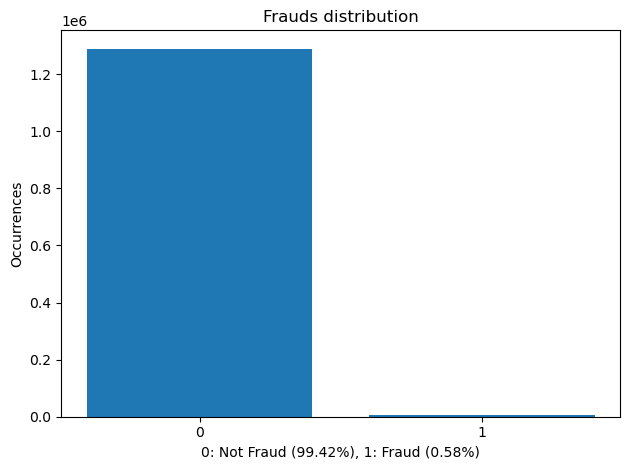

In [6]:
frauds=df["is_fraud"].value_counts()
fig,ax=plt.subplots()
ax.bar(frauds.index,frauds.values)
ax.set_xticks(frauds.index)
ax.set_title("Frauds distribution")
ax.set_xlabel(f"0: Not Fraud ({round(frauds[0]/frauds.sum()*100,2)}%), 1: Fraud ({round(frauds[1]/frauds.sum()*100,2)}%)")
ax.set_ylabel("Occurrences")

plt.tight_layout()
plt.show()

Fraudulent transactions account for ~0.58% of the dataset — a severe class imbalance. Standard accuracy is uninformative at this ratio; **PR-AUC** is the appropriate evaluation metric throughout. The imbalance also implies that an unsupervised model trained on normal data will see fraud only at inference time, making anomaly detection a natural fit.

#### Temporal patterns — `trans_date_trans_time`

Transaction timestamps are the first candidate for temporal signal. We examine the fraud rate by hour of day (both absolute count and rate), then check whether the day of the week, day of the month, or month of the year add further information.

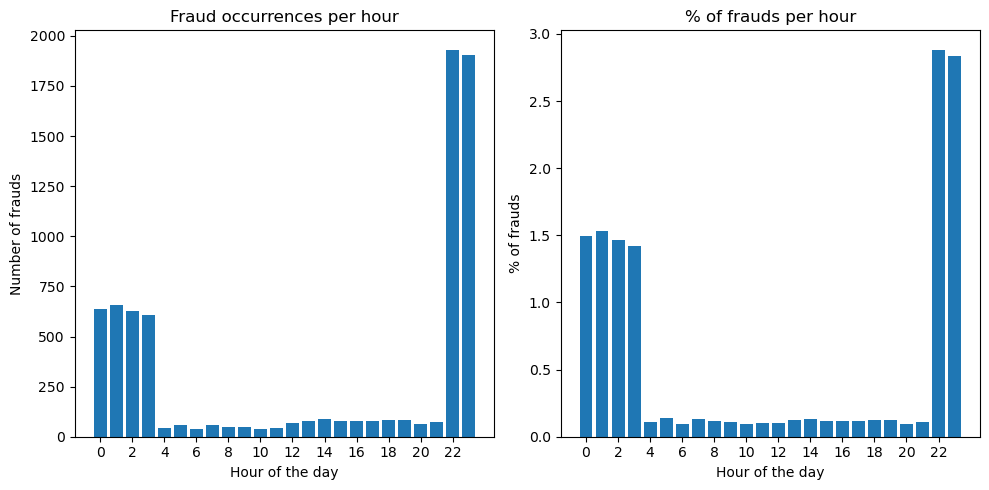

In [7]:
trans_hour=df["trans_date_trans_time"].dt.hour
fraud_hour=df["trans_date_trans_time"][df["is_fraud"]==1].dt.hour
trans_hour_counts=trans_hour.value_counts().sort_index()
fraud_hour_counts=fraud_hour.value_counts().sort_index()
perc_frauds=fraud_hour_counts/trans_hour_counts*100

fig,ax=plt.subplots(ncols=2, figsize=(10,5))
ax[0].bar(np.arange(24),fraud_hour_counts)
ax[0].set_xticks(np.arange(0,24,2))
ax[0].set_xlabel("Hour of the day")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Fraud occurrences per hour")

ax[1].bar(np.arange(24),perc_frauds)
ax[1].set_xticks(np.arange(0,24,2))
ax[1].set_xlabel("Hour of the day")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("% of frauds per hour")

plt.tight_layout()
plt.show()


Fraud is strongly concentrated between **10 PM and 3 AM** — both in absolute count and as a percentage of hourly transactions, ruling out any confound from varying volumes across the day.

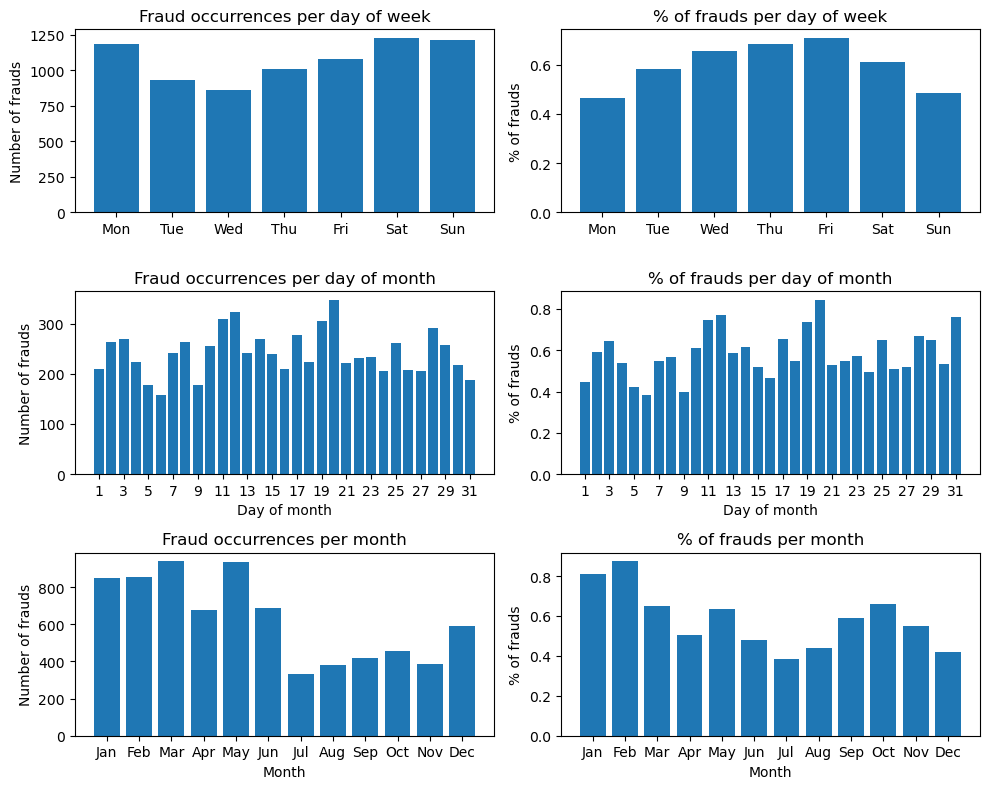

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=2,figsize=(10,8))

trans_dow = df["trans_date_trans_time"].dt.dayofweek
fraud_dow = df["trans_date_trans_time"][df["is_fraud"]==1].dt.dayofweek
trans_dow_counts = trans_dow.value_counts().sort_index()
fraud_dow_counts = fraud_dow.value_counts().sort_index()
perc_frauds_dow = (fraud_dow_counts / trans_dow_counts) * 100

dow = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

ax[0, 0].bar(trans_dow_counts.index, fraud_dow_counts)
ax[0, 0].set_xticks(range(7))
ax[0, 0].set_xticklabels(dow)
ax[0, 0].set_ylabel("Number of frauds")
ax[0, 0].set_title("Fraud occurrences per day of week")

ax[0, 1].bar(trans_dow_counts.index, perc_frauds_dow)
ax[0, 1].set_xticks(range(7))
ax[0, 1].set_xticklabels(dow)
ax[0, 1].set_ylabel("% of frauds")
ax[0, 1].set_title("% of frauds per day of week")

trans_dom = df["trans_date_trans_time"].dt.day
fraud_dom = df["trans_date_trans_time"][df["is_fraud"]==1].dt.day
trans_dom_counts = trans_dom.value_counts().sort_index()
fraud_dom_counts = fraud_dom.value_counts().sort_index()
perc_frauds_dom = (fraud_dom_counts / trans_dom_counts) * 100

ax[1, 0].bar(trans_dom_counts.index, fraud_dom_counts)
ax[1, 0].set_xticks(range(1, 32, 2))
ax[1, 0].set_xlabel("Day of month")
ax[1, 0].set_ylabel("Number of frauds")
ax[1, 0].set_title("Fraud occurrences per day of month")

ax[1, 1].bar(trans_dom_counts.index, perc_frauds_dom)
ax[1, 1].set_xticks(range(1, 32, 2))
ax[1, 1].set_xlabel("Day of month")
ax[1, 1].set_ylabel("% of frauds")
ax[1, 1].set_title("% of frauds per day of month")

trans_month = df["trans_date_trans_time"].dt.month
fraud_month = df["trans_date_trans_time"][df["is_fraud"] == 1].dt.month
trans_month_counts = trans_month.value_counts().sort_index()
fraud_month_counts = fraud_month.value_counts().sort_index()
perc_frauds_month = (fraud_month_counts / trans_month_counts) * 100

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax[2,0].bar(fraud_month_counts.index, fraud_month_counts.values)
ax[2,0].set_xticks(range(1, 13))
ax[2,0].set_xticklabels(months)
ax[2,0].set_xlabel("Month")
ax[2,0].set_ylabel("Number of frauds")
ax[2,0].set_title("Fraud occurrences per month")

ax[2,1].bar(perc_frauds_month.index, perc_frauds_month.values)
ax[2,1].set_xticks(range(1, 13))
ax[2,1].set_xticklabels(months)
ax[2,1].set_xlabel("Month")
ax[2,1].set_ylabel("% of frauds")
ax[2,1].set_title("% of frauds per month")

plt.tight_layout()
plt.show()

Broadening the temporal granularity yields no further signal. Neither the day of the week, day of the month, nor month of the year show a consistent pattern in the fraud rate. **Hour of day is the only informative temporal dimension** and is encoded as a cyclical sin/cos pair plus the binary `is_night` flag.

#### Transaction category — `category`

With 14 distinct categories, `category` provides a coarse partition of spending behaviour. We compare both absolute fraud count and per-category fraud rate to identify which categories are over-represented among fraudulent transactions.

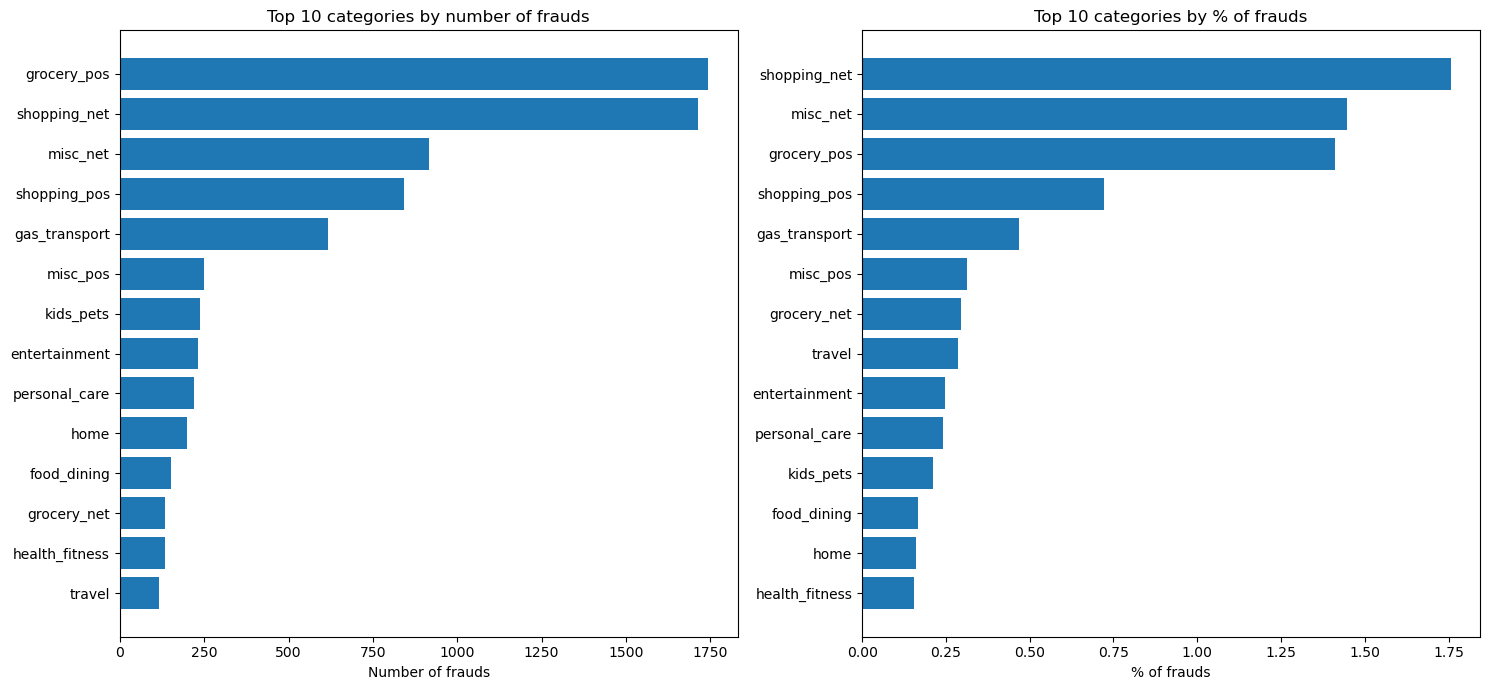

In [9]:
trans_cat = df["category"].value_counts()
fraud_cat = df[df["is_fraud"] == 1]["category"].value_counts()
perc_frauds_cat = (fraud_cat / trans_cat * 100).dropna().sort_values(ascending=True)
fraud_cat_sorted = fraud_cat.sort_values(ascending=True)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(fraud_cat_sorted.index, fraud_cat_sorted.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 categories by number of frauds")

ax[1].barh(perc_frauds_cat.index, perc_frauds_cat.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 categories by % of frauds")

plt.tight_layout()
plt.show()

The signal is clear: while everyday categories (groceries, gas) dominate in absolute transaction count, the fraud rate is concentrated in **online categories** — those ending with the *_net* suffix. This channel distinction will be encoded as the binary feature `is_online`. We next verify whether the `merchant` dimension adds anything beyond what `category` already captures.

#### Merchant identity — `merchant`

The dataset contains ~700 unique merchants, making individual-level fraud rates statistically unstable. We focus on the top 10 by absolute fraud count and by fraud rate, applying the same dual-perspective approach used throughout the EDA.

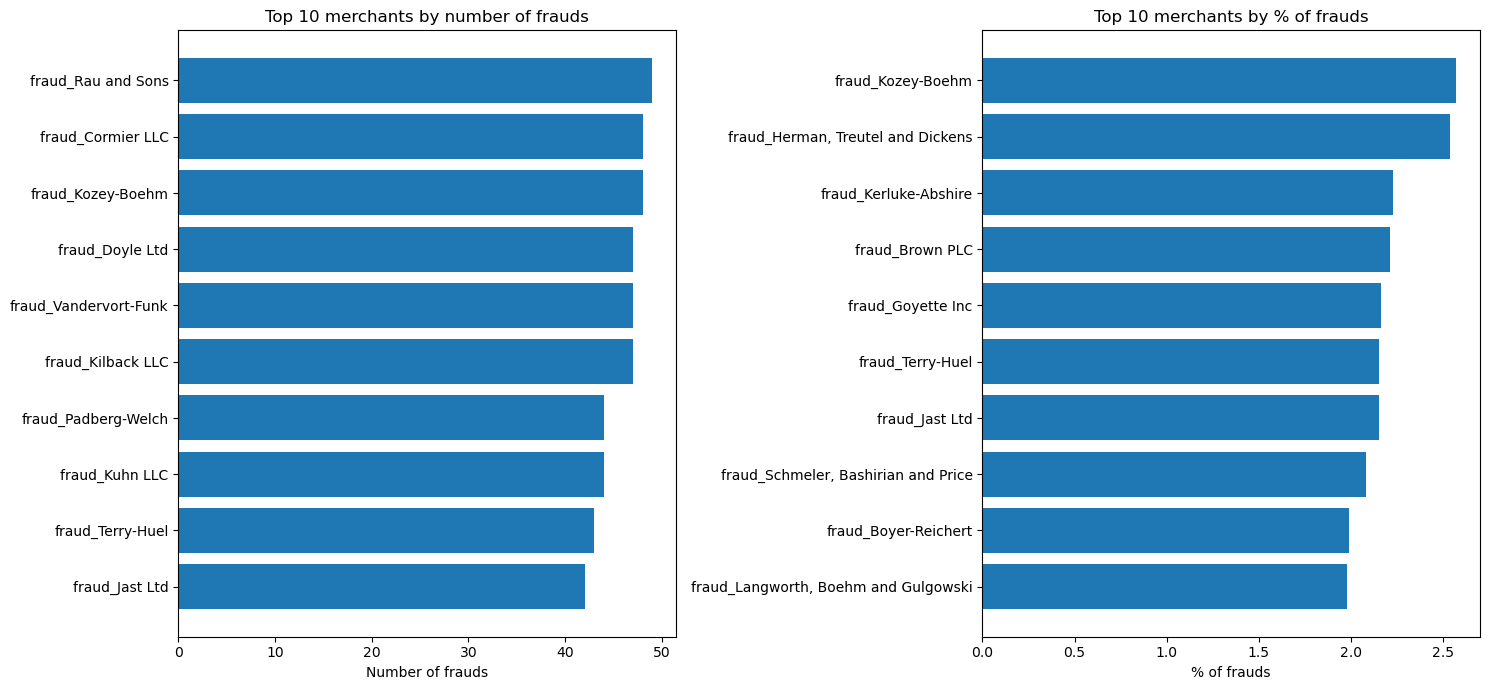

In [10]:
trans_merch = df['merchant'].value_counts()
fraud_merch = df[df['is_fraud'] == 1]['merchant'].value_counts()

top20_abs = fraud_merch.sort_values(ascending=True).tail(10)
top20_perc = (fraud_merch / trans_merch * 100).dropna().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(ncols=2, figsize=(15, 7))

ax[0].barh(top20_abs.index, top20_abs.values)
ax[0].set_xlabel("Number of frauds")
ax[0].set_title("Top 10 merchants by number of frauds")

ax[1].barh(top20_perc.index, top20_perc.values)
ax[1].set_xlabel("% of frauds")
ax[1].set_title("Top 10 merchants by % of frauds")

plt.tight_layout()
plt.show()

No consistent signal emerges. Merchants with the highest fraud *rates* are typically those with very few transactions — a statistical artefact. With ~700 unique values and no signal beyond what `category` already captures at cardinality 14, `merchant` will be dropped.

#### Transaction amount — `amt`

Transaction amounts span several orders of magnitude and are strongly right-skewed for both classes. We compare summary statistics, boxplots, and empirical distributions to quantify the difference between legitimate and fraudulent spending.

Stats legit transactions
count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64

Stats frauds
count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64


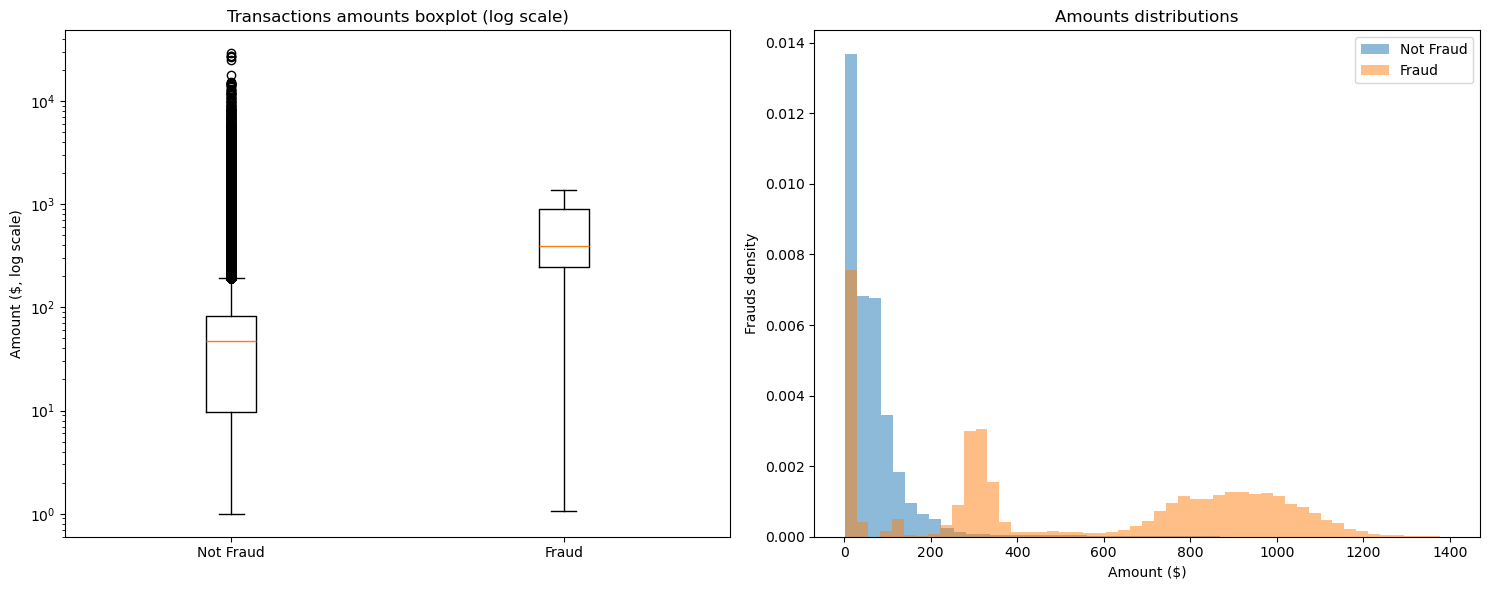

In [11]:
print("Stats legit transactions")
print(df[df['is_fraud'] == 0]['amt'].describe())
print("\nStats frauds")
print(df[df['is_fraud'] == 1]['amt'].describe())

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([df[df["is_fraud"]==0]["amt"], df[df["is_fraud"]==1]["amt"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log") 
ax[0].set_ylabel("Amount ($, log scale)")
ax[0].set_title("Transactions amounts boxplot (log scale)")

ax[1].hist(df[(df["is_fraud"]==0) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[(df["is_fraud"]==1) & (df["amt"] < 1400)]["amt"], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Amount ($)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Amounts distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

The distributions diverge clearly: legitimate transactions cluster below $100, while fraudulent ones are shifted upward with a heavier tail — the median fraud amount (~$117) is roughly 2.5× the legitimate median (~$47). The raw `amt` feature carries real signal but normalising it by category and by card history will amplify that signal further.

#### Cardholder age — `dob`

We examine whether the cardholder's birth year associates with fraud likelihood. Any observed pattern could reflect demographic targeting or simply mirror the age distribution of the active cardholder population.

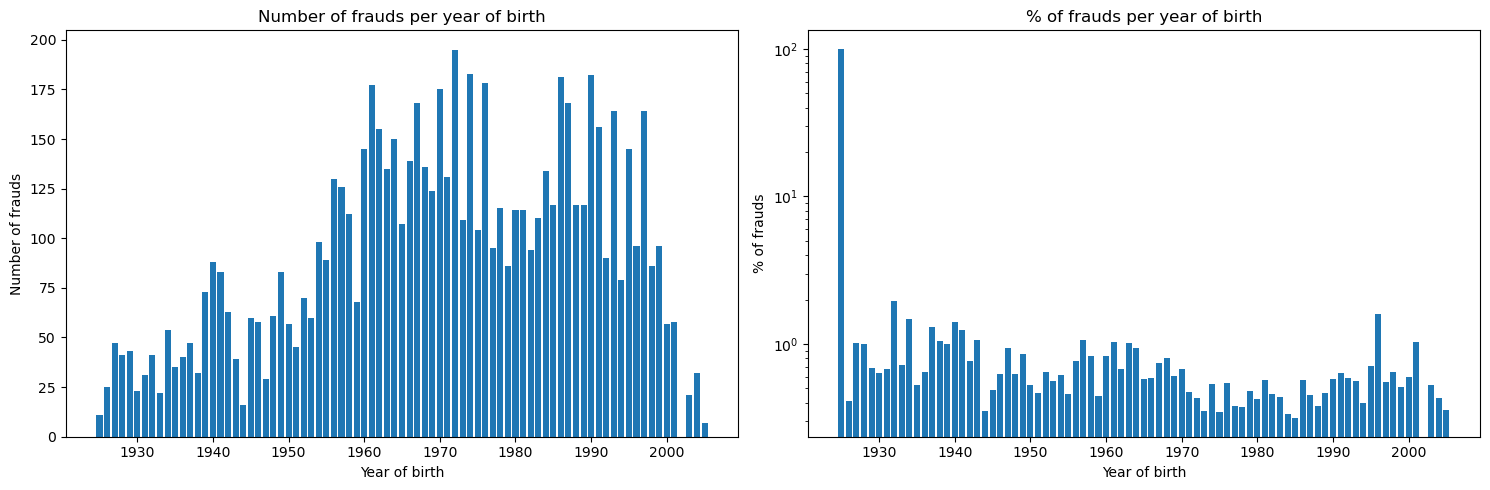

In [12]:
trans_yob = df["dob"].dt.year
fraud_yob = df[df["is_fraud"] == 1]["dob"].dt.year
trans_yob_counts = trans_yob.value_counts().sort_index()
fraud_yob_counts = fraud_yob.value_counts().sort_index()
perc_frauds_yob = (fraud_yob_counts / trans_yob_counts) * 100

fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].bar(fraud_yob_counts.index, fraud_yob_counts.values)
ax[0].set_xlabel("Year of birth")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Number of frauds per year of birth")


ax[1].bar(perc_frauds_yob.index, perc_frauds_yob.values)
ax[1].set_xlabel("Year of birth")
ax[1].set_ylabel("% of frauds")
ax[1].set_yscale("log")
ax[1].set_title("% of frauds per year of birth")


plt.tight_layout()
plt.show()

In [13]:
df[df["dob"].dt.year==1925][["cc_num","is_fraud"]].value_counts()

cc_num            is_fraud
4492677353108006  1           11
Name: count, dtype: int64

The fraud count by birth year mirrors the active cardholder population (concentrated 1960–2000), with no age-related signal in the fraud rate. The outlier at 1925 is explained by a single compromised card. `dob` carries no predictive signal and will be dropped.

#### Home-to-merchant distance

Using the Haversine formula, we compute the great-circle distance between the cardholder's registered home address (`lat`, `long`) and the merchant location (`merch_lat`, `merch_long`) to check whether fraudsters tend to operate far from the cardholder's home.

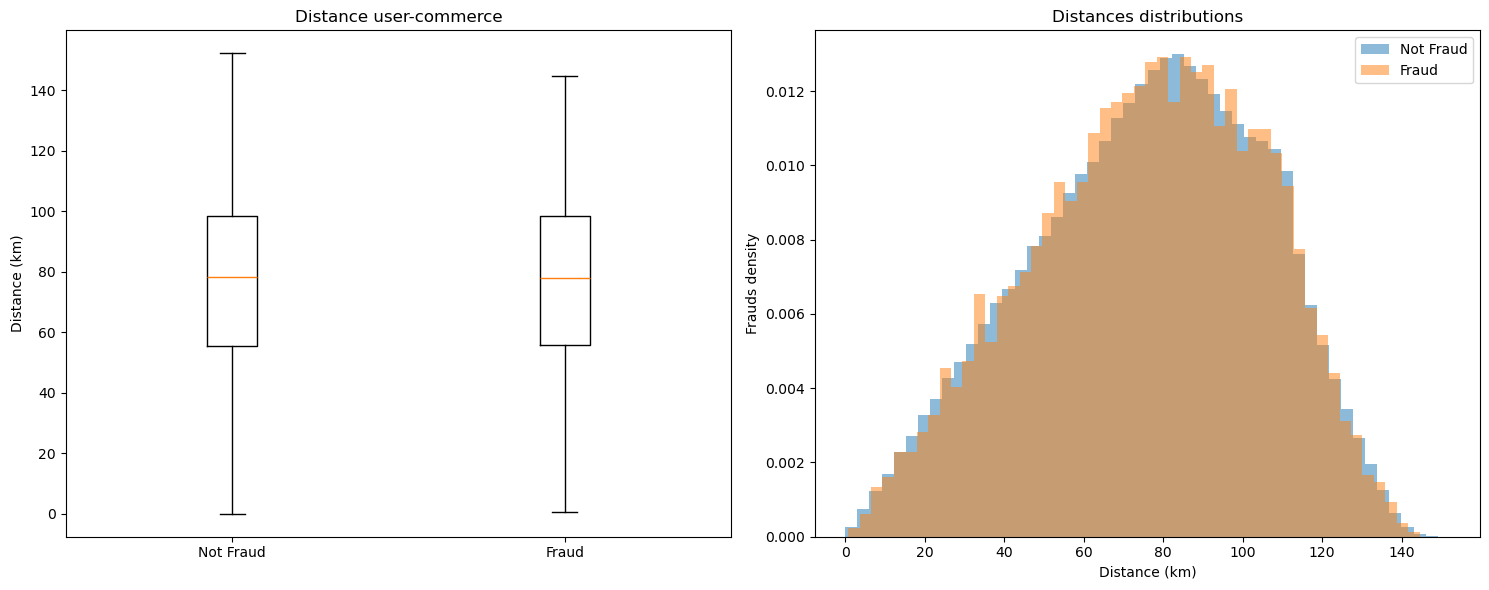

In [14]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    d=R*c
    return d

dist_km = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].boxplot([dist_km[df["is_fraud"]==0], dist_km[df["is_fraud"]==1]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Distance user-commerce")

ax[1].hist(dist_km[df["is_fraud"]==0], bins=50, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(dist_km[df["is_fraud"]==1], bins=50, alpha=0.5, label="Fraud", density=True)
ax[1].set_xlabel("Distance (km)")
ax[1].set_ylabel("Frauds density")
ax[1].set_title("Distances distributions")
ax[1].legend()

plt.tight_layout()
plt.show()

Both boxplots and empirical distributions are nearly identical for fraudulent and legitimate transactions — geographical distance from home carries no useful signal. This rules out a simple "proximity to home" fraud heuristic.

#### Geographic context — `city_pop` and `state`

We check the two remaining geographic features: the population of the cardholder's city of residence and the US state. Raw lat/long coordinates are not analysed at finer granularity — the high dimensionality would introduce noise rather than signal.

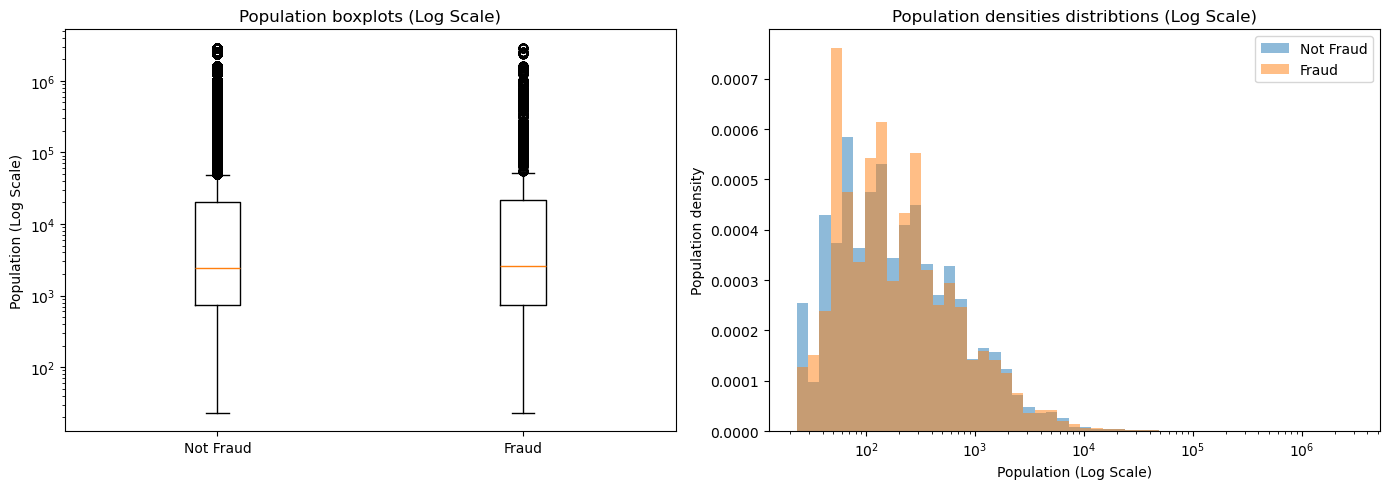

In [15]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([df[df["is_fraud"]==0]["city_pop"], df[df["is_fraud"]==1]["city_pop"]], tick_labels=["Not Fraud", "Fraud"])
ax[0].set_yscale("log")
ax[0].set_ylabel("Population (Log Scale)")
ax[0].set_title("Population boxplots (Log Scale)")

bins = np.logspace(np.log10(df['city_pop'].min()), np.log10(df['city_pop'].max()), 50)
ax[1].hist(df[df["is_fraud"]==0]["city_pop"], bins=bins, alpha=0.5, label="Not Fraud", density=True)
ax[1].hist(df[df["is_fraud"]==1]["city_pop"], bins=bins, alpha=0.5, label="Fraud", density=True)
ax[1].set_xscale("log")
ax[1].set_xlabel("Population (Log Scale)")
ax[1].set_ylabel("Population density")
ax[1].set_title("Population densities distribtions (Log Scale)")
ax[1].legend()

plt.tight_layout()
plt.show()

City population distributions are nearly identical across classes — no signal here either.

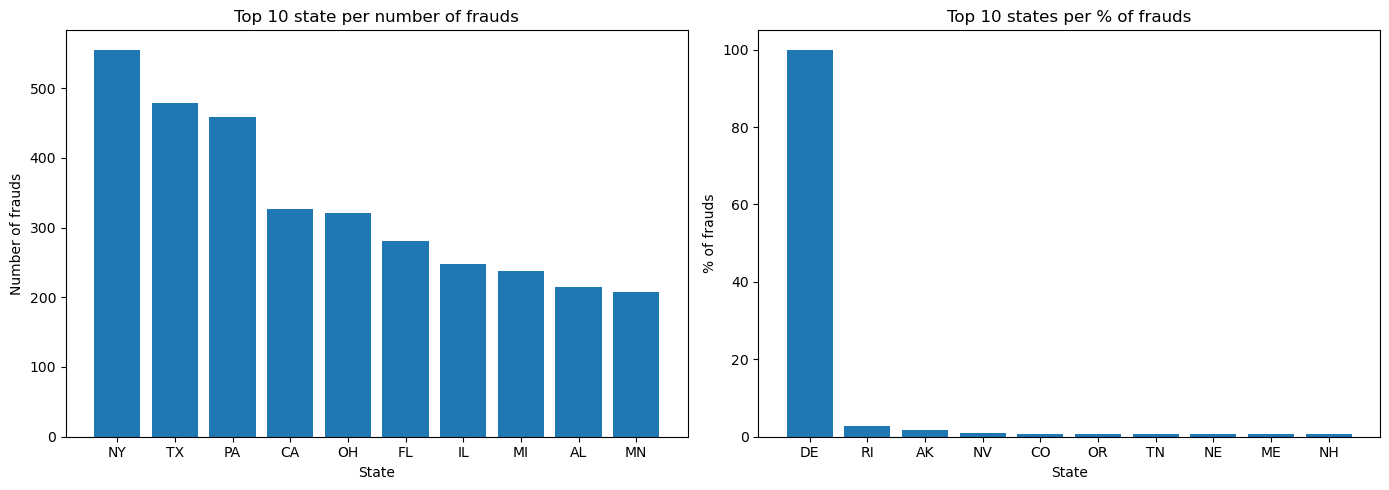

In [16]:
trans_state = df['state'].value_counts()
fraud_state = df[df['is_fraud']==1]['state'].value_counts()

top10_abs = fraud_state.sort_values(ascending=False).head(10)
perc_state = (fraud_state / trans_state * 100).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(top10_abs.index, top10_abs.values)
ax[0].set_xlabel("State")
ax[0].set_ylabel("Number of frauds")
ax[0].set_title("Top 10 state per number of frauds")

ax[1].bar(perc_state.index, perc_state.values)
ax[1].set_xlabel("State")
ax[1].set_ylabel("% of frauds")
ax[1].set_title("Top 10 states per % of frauds")

plt.tight_layout()
plt.show()

In [17]:
df[df['state']=='DE'][["cc_num","state","is_fraud"]].value_counts()

cc_num            state  is_fraud
6011826317034777  DE     1           9
Name: count, dtype: int64

No state shows a disproportionately high fraud count. Delaware (DE) appears to stand out in relative terms, but the lookup confirms it is driven by a single compromised card — the same artefact as the 1925 birth year. No geographic feature at any granularity carries actionable signal.

#### Inter-transaction time — `hours_since_last_trans`

Beyond the hour of the day, fraud may also manifest as an unusual *pace* of transactions. We compute the time elapsed between consecutive transactions on the same card and compare the distributions.

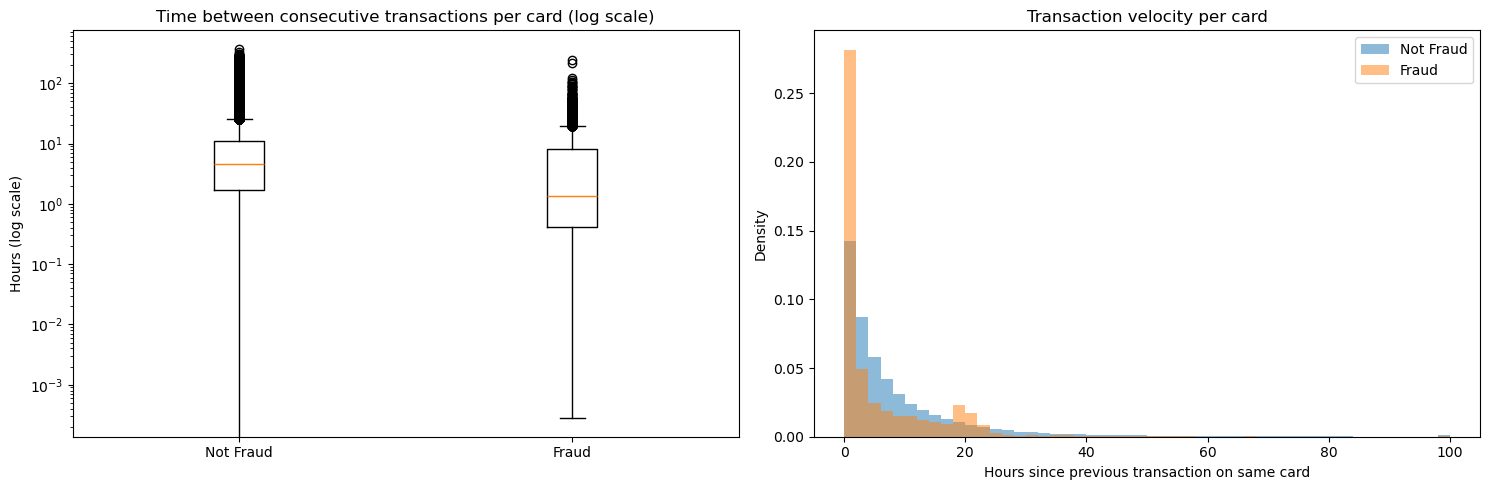

Median hours since last transaction — Not Fraud: 4.6h
Median hours since last transaction — Fraud:     1.4h


In [18]:
df_vel = df[['cc_num', 'unix_time', 'is_fraud']].sort_values(['cc_num', 'unix_time'])
df_vel['hours_since_last'] = df_vel.groupby('cc_num')['unix_time'].diff() / 3600

legit_intervals = df_vel[df_vel['is_fraud'] == 0]['hours_since_last'].dropna()
fraud_intervals = df_vel[df_vel['is_fraud'] == 1]['hours_since_last'].dropna()

clip_h = 100
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

ax[0].boxplot([legit_intervals, fraud_intervals], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Hours (log scale)')
ax[0].set_title('Time between consecutive transactions per card (log scale)')

ax[1].hist(legit_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_intervals.clip(upper=clip_h), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Hours since previous transaction on same card')
ax[1].set_ylabel('Density')
ax[1].set_title('Transaction velocity per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median hours since last transaction — Not Fraud: {legit_intervals.median():.1f}h")
print(f"Median hours since last transaction — Fraud:     {fraud_intervals.median():.1f}h")

Fraudulent transactions occur significantly closer together in time: the median interval drops from **4.6 hours** (legitimate) to **1.4 hours** (fraud) — a 3.3× difference. This burst pattern is consistent with a card being used intensively in a short window. `hours_since_last_trans` is a strong feature candidate.

#### Amount z-scores — `amt_zscore_cat` and `amt_zscore_card`

The raw `amt` carries signal, but its discriminative power increases when normalised relative to the expected spend for a given context. We engineer two complementary z-scores to capture both dimensions.

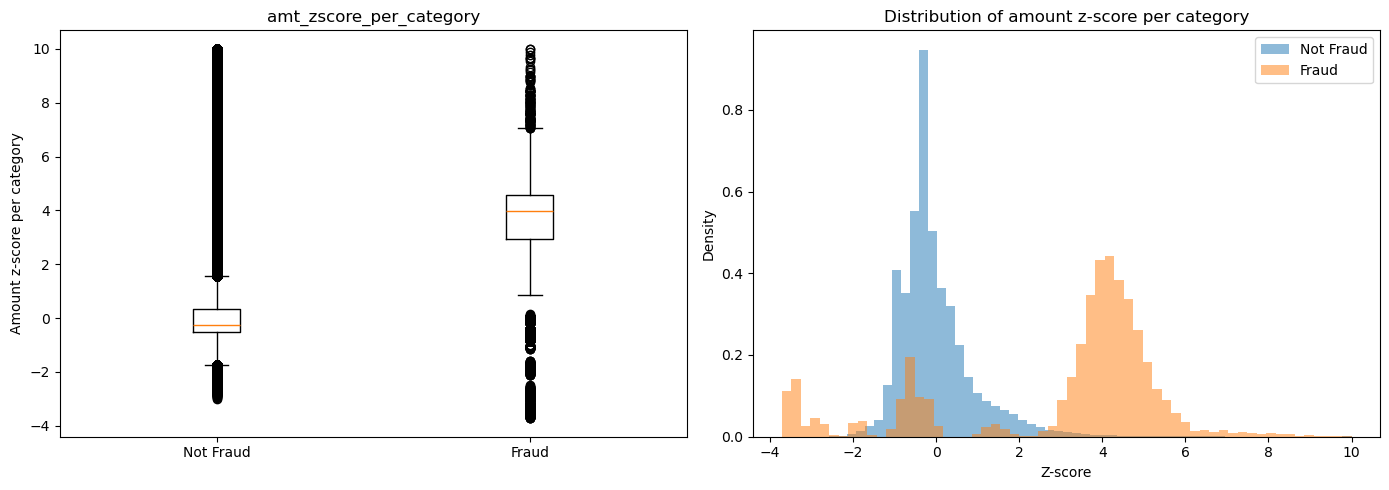

Median z-score amount per category — Not Fraud: -0.26
Median z-score amount per category — Fraud:     3.98


In [19]:
cat_mean = df[df['is_fraud'] == 0].groupby('category')['amt'].mean()
cat_std  = df[df['is_fraud'] == 0].groupby('category')['amt'].std()

amt_z   = (df['amt'] - df['category'].map(cat_mean)) / (df['category'].map(cat_std) + 1e-6)
legit_z = amt_z[df['is_fraud'] == 0]
fraud_z = amt_z[df['is_fraud'] == 1]

clip_z = 10
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_z.clip(-clip_z, clip_z), fraud_z.clip(-clip_z, clip_z)], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per category')
ax[0].set_title('amt_zscore_per_category')

ax[1].hist(legit_z.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_z.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel('Z-score')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of amount z-score per category')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median z-score amount per category — Not Fraud: {legit_z.median():.2f}")
print(f"Median z-score amount per category — Fraud:     {fraud_z.median():.2f}")


`amt_zscore_cat` normalises the amount relative to the category baseline — but two cardholders in the same category can have very different spending habits. We visualise `amt_zscore_card` to capture how anomalous a given amount is *for this specific card*.

**Note on temporal leakage.** This EDA cell uses a full-history per-card mean and std for visualisation only (non-causal). In the models, `amt_zscore_card` is computed with an expanding window and a one-step shift so each transaction sees only its own past. `amt_zscore_cat` uses the training-set category mean: technically non-causal, but stable category-level aggregates over hundreds of thousands of transactions make the impact negligible.

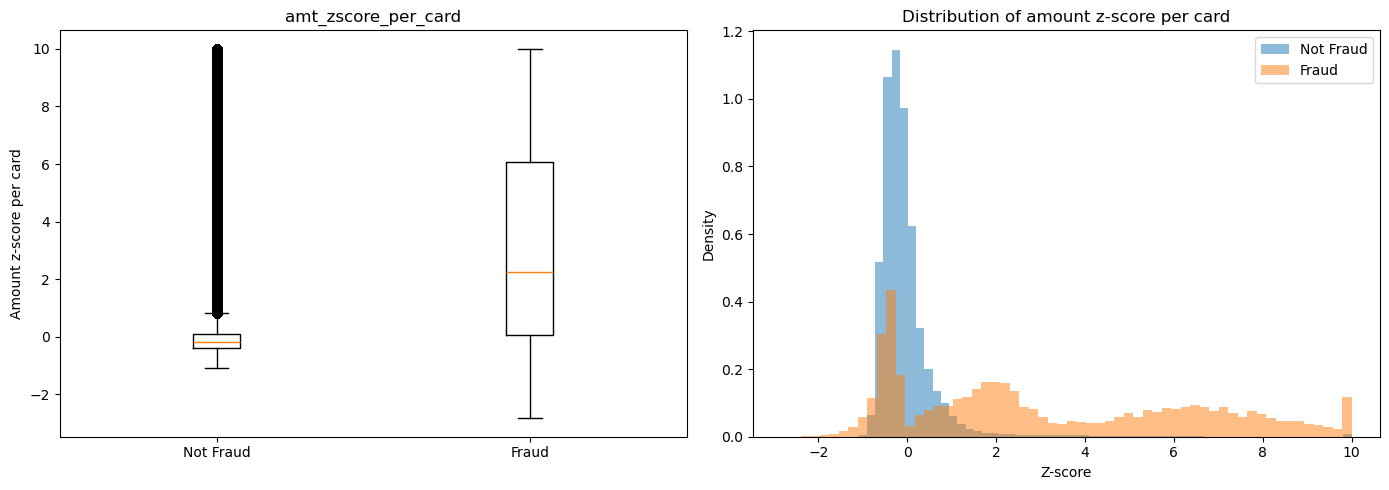

Median z-score amount per card — Not Fraud: -0.18
Median z-score amount per card — Fraud:     2.26


In [20]:
card_mean  = df.groupby('cc_num')['amt'].transform('mean')
card_std   = df.groupby('cc_num')['amt'].transform('std')
amt_z_card = (df['amt'] - card_mean) / (card_std + 1e-6)

legit_zc = amt_z_card[df['is_fraud'] == 0]
fraud_zc = amt_z_card[df['is_fraud'] == 1]

clip_z = 10
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].boxplot([legit_zc.clip(-clip_z, clip_z), fraud_zc.clip(-clip_z, clip_z)], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_ylabel('Amount z-score per card')
ax[0].set_title('amt_zscore_per_card')

ax[1].hist(legit_zc.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fraud_zc.clip(-clip_z, clip_z), bins=60, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel('Z-score')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of amount z-score per card')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median z-score amount per card — Not Fraud: {legit_zc.median():.2f}")
print(f"Median z-score amount per card — Fraud:     {fraud_zc.median():.2f}")

Three further features complete the model set. `is_online` is derived directly from the category EDA above (binary flag for `_net` categories). `is_night` and `n_prev_tx_card` require dedicated visualisation below.

#### Nighttime flag — `is_night`

The hourly EDA identified a sharp, discontinuous fraud spike concentrated between **22:00 and 4:00**. The cyclical sin/cos encoding represents hour as a smooth wave, but the crime window is a hard 6-hour range. A binary flag directly exposes the strongest temporal signal in the dataset without requiring any model to learn the discontinuity from curvature.

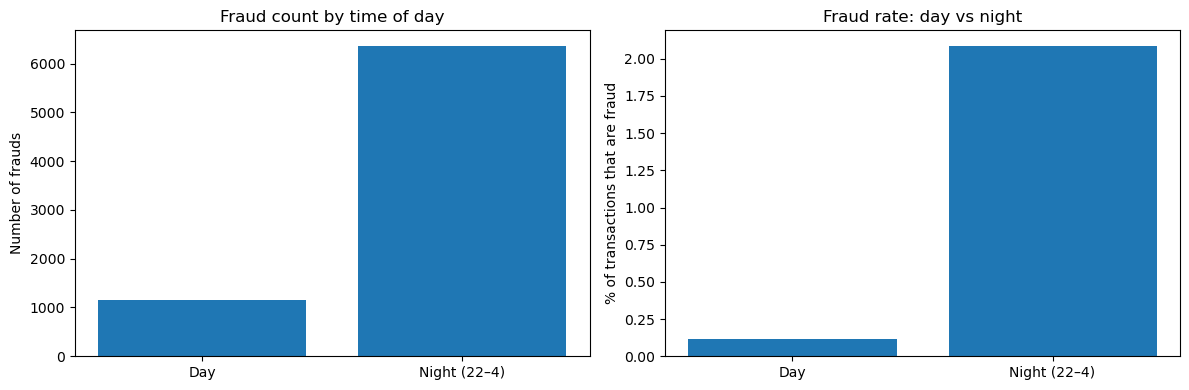

Fraud rate — Day (4:00-22:00):   0.12%
Fraud rate — Night (22:00–4:00): 2.09%


In [21]:
_hour_eda = df['trans_date_trans_time'].dt.hour
df_night  = df.copy()
df_night['is_night'] = _hour_eda.isin([22, 23, 0, 1, 2, 3]).astype(int)

trans_night = df_night['is_night'].value_counts()
fraud_night  = df_night[df_night['is_fraud'] == 1]['is_night'].value_counts()
perc_night   = (fraud_night / trans_night * 100).reindex([0, 1]).fillna(0)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4))
ax[0].bar(['Day', 'Night (22–4)'], [fraud_night.get(0, 0), fraud_night.get(1, 0)])
ax[0].set_ylabel('Number of frauds')
ax[0].set_title('Fraud count by time of day')

ax[1].bar(['Day', 'Night (22–4)'], perc_night.values)
ax[1].set_ylabel('% of transactions that are fraud')
ax[1].set_title('Fraud rate: day vs night')

plt.tight_layout()
plt.show()

print(f"Fraud rate — Day (4:00-22:00):   {perc_night[0]:.2f}%")
print(f"Fraud rate — Night (22:00–4:00): {perc_night[1]:.2f}%")

The nighttime fraud rate is approximately **17×** the daytime rate (2.09% vs 0.12%). `is_night` condenses the strongest temporal signal in the dataset into a single binary feature, making the 22:00–3:00 crime window directly accessible to models without requiring them to learn a threshold on the continuous sin/cos encoding.

#### Card history depth — `n_prev_tx_card`

`amt_zscore_card` relies on an expanding mean that is statistically unreliable when few prior transactions are available — a zscore computed on 3 transactions carries far less information than one computed on 800. `n_prev_tx_card` (count of prior transactions on the same card) makes this cold-start uncertainty explicit. It also carries a weak direct signal: fraud cards in this dataset tend to have shorter recorded histories than legitimate ones, consistent with newly cloned or recently issued cards.

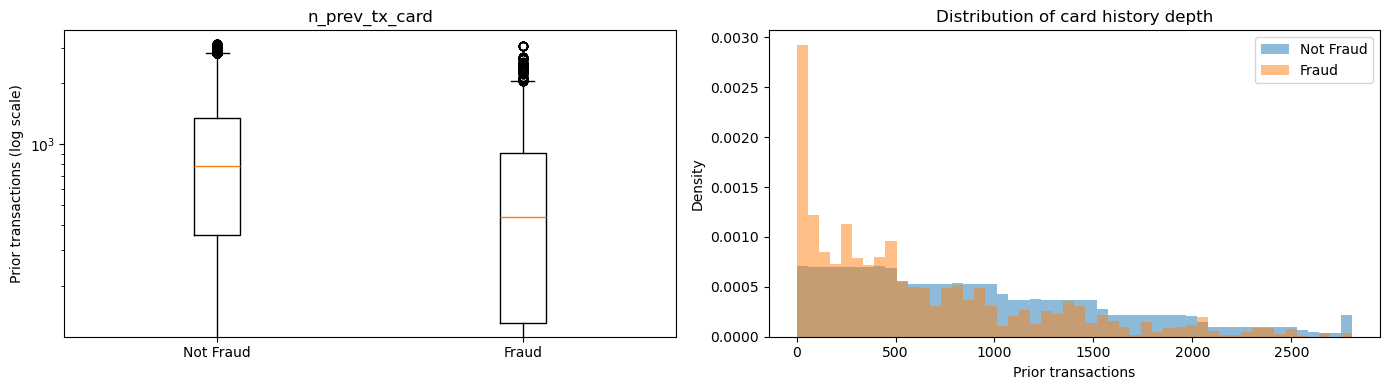

Median number of previous transactions per card — Not Fraud: 779
Median number of previous transactions per card — Fraud:     438


In [22]:
_df_np  = df.sort_values(['cc_num', 'unix_time'])
_n_prev = _df_np.groupby('cc_num').cumcount()
_n_prev.index = _df_np.index

lv_np   = _n_prev[df['is_fraud'] == 0]
fv_np   = _n_prev[df['is_fraud'] == 1]
clip_np = int(lv_np.quantile(0.99))

fig, ax = plt.subplots(ncols=2, figsize=(14, 4))
ax[0].boxplot([lv_np, fv_np], tick_labels=['Not Fraud', 'Fraud'])
ax[0].set_yscale('log')
ax[0].set_ylabel('Prior transactions (log scale)')
ax[0].set_title('n_prev_tx_card')
ax[1].hist(lv_np.clip(upper=clip_np), bins=50, alpha=0.5, label='Not Fraud', density=True)
ax[1].hist(fv_np.clip(upper=clip_np), bins=50, alpha=0.5, label='Fraud', density=True)
ax[1].set_xlabel(f'Prior transactions')
ax[1].set_ylabel('Density')
ax[1].set_title('Distribution of card history depth')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Median number of previous transactions per card — Not Fraud: {lv_np.median():.0f}")
print(f"Median number of previous transactions per card — Fraud:     {fv_np.median():.0f}")

The distributions overlap substantially (median ~438 for fraud vs ~779 for legitimate, a 1.8× ratio), confirming that `n_prev_tx_card` is not a reliable standalone discriminator. Its primary role is contextual: it calibrates how much trust to place in the card-level aggregates and signals cold-start conditions to the models.

## Metrics evaluation function

In [23]:
def evaluate_model(y_val, y_proba, model_name="Model", threshold=0.5, plot=True):
    y_pred  = (y_proba >= threshold).astype(int)

    print(f"\n{'═'*44}")
    print(f"  {model_name}")
    print(f"{'─'*44}")
    print(f"  PR-AUC  (primary)   {average_precision_score(y_val, y_proba):.4f}")
    print(f"  ROC-AUC             {roc_auc_score(y_val, y_proba):.4f}")
    print(f"{'─'*44}")
    print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))
    print(f"{'═'*44}\n")

    if not plot:
        return

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

    PrecisionRecallDisplay.from_predictions(y_val, y_proba, ax=axes[0, 0])
    axes[0, 0].set_title('Precision-Recall Curve')

    RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[0, 1])
    axes[0, 1].set_title('ROC Curve')

    prec, rec, thr = precision_recall_curve(y_val, y_proba)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    best_idx = int(np.argmax(f1))
    axes[1, 0].plot(thr, f1, color='steelblue', lw=1.5)
    axes[1, 0].axvline(thr[best_idx], color='green', ls='--', lw=1.2,
                       label=f'Max F1 = {f1[best_idx]:.3f}  @  thr = {thr[best_idx]:.4f}')
    axes[1, 0].axvline(threshold, color='tomato', ls=':', lw=1.5,
                       label=f'Chosen thr = {threshold:.4f}')
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].set_title('F1 Score vs Threshold')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].set_xlim(0, max(thr[best_idx], threshold) * 1.5)

    ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=axes[1, 1],
                                            display_labels=['Not Fraud', 'Fraud'])
    axes[1, 1].set_title(f'Confusion Matrix  (thr = {threshold:.4f})')

    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Fase 1 — Supervised Models

We establish the supervised ceiling with full label access. **Logistic Regression** serves as the linear baseline; **LightGBM** as the non-linear champion. Both share the same core features — inter-transaction time, and card- and category-level amount z-scores — but differ in encoding: LogReg applies log-transforms and cyclical hour encoding (`hour_sin`, `hour_cos`); LightGBM works with raw values and handles non-linearities natively via tree splits.

This section answers a single question: *how well can a supervised model perform when fraud labels are abundant?* The answer sets the benchmark against which the label-free models in Fase 2 are measured.

### Held-out Test Set

`fraudTest.csv` covers Jun–Dec 2020 — the six months immediately following the training period. It is loaded here, after the EDA has established all transformations that will be applied to it. The test set is never used to fit any parameter or select any threshold; it is reserved exclusively for final evaluation.

In [24]:
df_test_raw = pd.read_csv("archive/fraudTest.csv", index_col="Unnamed: 0")
df_test_raw["trans_date_trans_time"] = pd.to_datetime(df_test_raw["trans_date_trans_time"])
df_test_raw["dob"] = pd.to_datetime(df_test_raw["dob"])

### Dataset Modification -- Amplified Fraud Signal

To demonstrate the potential of unsupervised anomaly detection under realistic card-compromise conditions, we amplify two EDA-identified axes of the synthetic dataset.

| Modification | Formula | Target feature |
|---|---|---|
| Amount | `card_mean_legit + 9σ` | `amt_zscore_card`, `amt_zscore_cat` |
| Timing | previous tx + 5-30 min | `hours_since_last_trans` |

The original dataset represents subtle CNP/online fraud where individual transactions are hard to distinguish from normal purchases. The modification simulates physical card compromise or account takeover -- large unauthorised transactions in rapid succession -- the use case for which unsupervised anomaly detection is most effective. All models (supervised and unsupervised) are evaluated on the same modified dataset.

In [25]:
def _amplify_fraud(df, k_amt=9.0, seed=42):
    """
    Amplifies fraud transactions along the two most discriminative EDA axes:
    1. Amount: card_mean_legit + k_amt * card_std_legit
    2. Timing: previous tx + 1-5 minutes (tight burst pattern)
    """
    rng = np.random.default_rng(seed)
    df  = df.copy().sort_values(['cc_num', 'unix_time'])

    card_stats = (df[df['is_fraud'] == 0]
                  .groupby('cc_num')['amt']
                  .agg(mean='mean', std='std'))
    card_stats['std'] = card_stats['std'].fillna(card_stats['mean'] * 0.3).clip(lower=1.0)

    fraud_mask = df['is_fraud'] == 1

    # 1. Amount amplification
    target_amt = (df.loc[fraud_mask, 'cc_num']
                  .map(card_stats['mean'] + k_amt * card_stats['std']))
    df.loc[fraud_mask, 'amt'] = target_amt.clip(lower=1.0).fillna(df.loc[fraud_mask, 'amt'])

    # 2. Burst timing
    df['_prev_unix'] = df.groupby('cc_num')['unix_time'].shift(1)
    has_prev = fraud_mask & df['_prev_unix'].notna()
    deltas = rng.integers(60, 300, size=int(has_prev.sum()))
    df.loc[has_prev, 'unix_time'] = (df.loc[has_prev, '_prev_unix'].values + deltas).astype(int)
    df = df.drop(columns=['_prev_unix']).sort_index()
    return df

df          = _amplify_fraud(df)
df_test_raw = _amplify_fraud(df_test_raw)

print(f"Fraud amt  median={df[df.is_fraud==1]['amt'].median():.0f}  "
      f"mean={df[df.is_fraud==1]['amt'].mean():.0f}")
print(f"Normal amt median={df[df.is_fraud==0]['amt'].median():.0f}  "
      f"mean={df[df.is_fraud==0]['amt'].mean():.0f}")

Fraud amt  median=998  mean=1167
Normal amt median=47  mean=68


### Supervised Baseline — Logistic Regression

Logistic Regression establishes the supervised baseline. With `class_weight='balanced'` the model reweights the minority class to compensate for the ~170:1 imbalance. Log-transforming `amt` and `hours_since_last_trans` linearises their right-skewed distributions, making them accessible to a linear decision boundary. Any non-linear method should comfortably surpass this baseline.

### Feature Engineering

In [26]:
df_baseline = df.copy()
df_baseline = df_baseline.sort_values(['cc_num', 'unix_time'])

df_baseline['hours_since_last_trans'] = df_baseline.groupby('cc_num')['unix_time'].diff() / 3600
df_baseline['hours_since_last_trans'] = df_baseline['hours_since_last_trans'].fillna(
    df_baseline['hours_since_last_trans'].median()
)

_hour = df_baseline['trans_date_trans_time'].dt.hour
df_baseline['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_baseline['hour_cos'] = np.cos(2 * np.pi * _hour / 24)

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()
df_baseline['amt_zscore_cat'] = (
    (df_baseline['amt'] - df_baseline['category'].map(_cat_mean))
    / (df_baseline['category'].map(_cat_std) + 1e-6)
)

_g = df_baseline.groupby('cc_num')['amt']
df_baseline['amt_zscore_card'] = (
    (df_baseline['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

df_baseline['amt']                   = np.log1p(df_baseline['amt'])
df_baseline['hours_since_last_trans'] = np.log1p(df_baseline['hours_since_last_trans'])

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_baseline = df_baseline.drop(columns=cols_to_drop).sort_index()

In [27]:
X = df_baseline.drop(columns=['is_fraud'])
y = df_baseline['is_fraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

num_features = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos', 'amt_zscore_cat', 'amt_zscore_card']
cat_features = ['category']

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('scaler', StandardScaler(), num_features)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Evaluation

In [28]:
y_proba_lr = pipe.predict_proba(X_val)[:, 1]
evaluate_model(y_val, y_proba_lr, "Logistic Regression — Validation", plot=False)


════════════════════════════════════════════
  Logistic Regression — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.8150
  ROC-AUC             0.9899
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    257797
       Fraud       0.26      0.97      0.42      1538

    accuracy                           0.98    259335
   macro avg       0.63      0.98      0.70    259335
weighted avg       1.00      0.98      0.99    259335

════════════════════════════════════════════




════════════════════════════════════════════
  Logistic Regression — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.7669
  ROC-AUC             0.9928
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    553574
       Fraud       0.18      0.98      0.31      2145

    accuracy                           0.98    555719
   macro avg       0.59      0.98      0.65    555719
weighted avg       1.00      0.98      0.99    555719

════════════════════════════════════════════



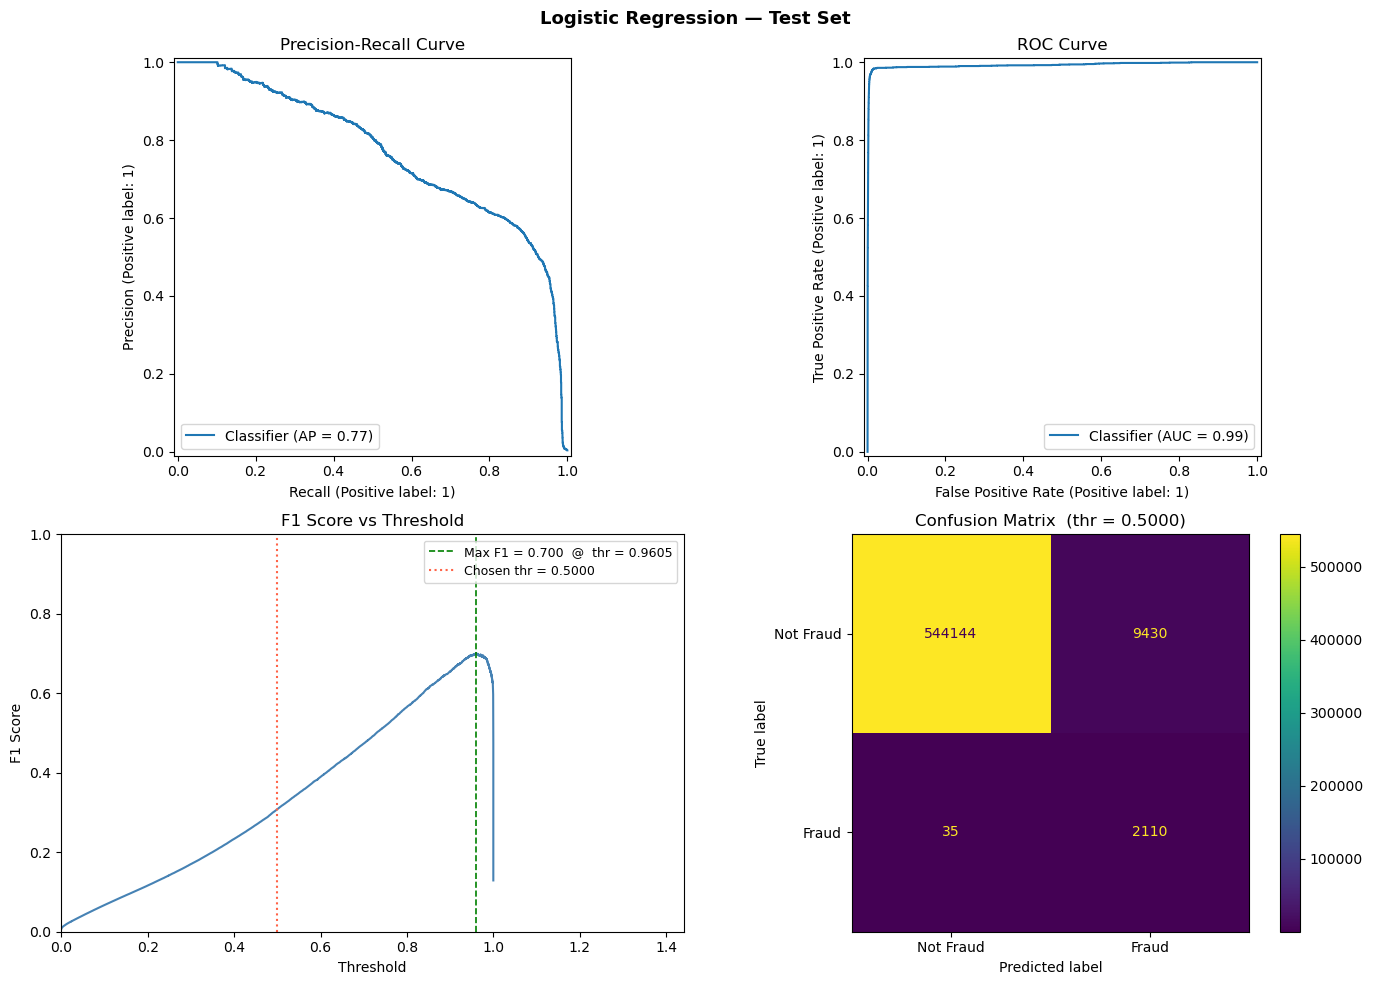

In [29]:
# Per-card statistics extracted from training
_tr_sorted   = df.sort_values(['cc_num', 'unix_time'])
_tr_last_t   = _tr_sorted.groupby('cc_num')['unix_time'].last()
_tr_card_mean = _tr_sorted.groupby('cc_num')['amt'].mean()
_tr_card_std  = _tr_sorted.groupby('cc_num')['amt'].std()

df_test_lr = df_test_raw.copy().sort_values(['cc_num', 'unix_time'])

df_test_lr['hours_since_last_trans'] = df_test_lr.groupby('cc_num')['unix_time'].diff() / 3600
_is_first = df_test_lr.groupby('cc_num').cumcount() == 0
df_test_lr.loc[_is_first, 'hours_since_last_trans'] = (
    (df_test_lr.loc[_is_first, 'unix_time']
     - df_test_lr.loc[_is_first, 'cc_num'].map(_tr_last_t)) / 3600
)
df_test_lr['hours_since_last_trans'] = df_test_lr['hours_since_last_trans'].fillna(
    df_test_lr['hours_since_last_trans'].median()
)

_hour_te = df_test_lr['trans_date_trans_time'].dt.hour
df_test_lr['hour_sin'] = np.sin(2 * np.pi * _hour_te / 24)
df_test_lr['hour_cos'] = np.cos(2 * np.pi * _hour_te / 24)

df_test_lr['amt_zscore_cat'] = (
    (df_test_lr['amt'] - df_test_lr['category'].map(_cat_mean))
    / (df_test_lr['category'].map(_cat_std) + 1e-6)
)
df_test_lr['amt_zscore_card'] = (
    (df_test_lr['amt'] - df_test_lr['cc_num'].map(_tr_card_mean))
    / (df_test_lr['cc_num'].map(_tr_card_std) + 1e-6)
).fillna(0)

df_test_lr['amt']                    = np.log1p(df_test_lr['amt'])
df_test_lr['hours_since_last_trans'] = np.log1p(df_test_lr['hours_since_last_trans'])

_cols_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender', 'street', 'city',
              'state', 'zip', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop',
              'job', 'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_test_lr = df_test_lr.drop(columns=_cols_drop).sort_index()

X_test_lr = df_test_lr.drop(columns=['is_fraud'])
y_test_lr  = df_test_lr['is_fraud']

y_proba_lr_test = pipe.predict_proba(X_test_lr)[:, 1]
evaluate_model(y_test_lr, y_proba_lr_test, "Logistic Regression — Test Set")

Val PR-AUC **0.2489** → Test **0.1842**. Recall stable (~80%), precision 4%→2%. ROC-AUC unchanged (0.9275→0.9268). Drop driven by lower test fraud rate (0.39% vs 0.58%).

### Supervised Advanced — LightGBM

LightGBM is a gradient-boosted tree framework optimised for large tabular datasets. It captures non-linear feature interactions natively without requiring manual transformations — `hour` is kept raw rather than cyclically encoded since tree splits handle the 23→0 boundary automatically. The `scale_pos_weight` parameter rebalances the positive class in proportion to the training class ratio. Early stopping on the validation set prevents overfitting beyond the optimal tree count.

### Feature Engineering

In [30]:
df_lgbm = df.copy()
df_lgbm = df_lgbm.sort_values(['cc_num', 'unix_time'])

df_lgbm['hours_since_last_trans'] = df_lgbm.groupby('cc_num')['unix_time'].diff() / 3600
df_lgbm['hours_since_last_trans'] = df_lgbm['hours_since_last_trans'].fillna(
    df_lgbm['hours_since_last_trans'].median()
)
df_lgbm['hour'] = df_lgbm['trans_date_trans_time'].dt.hour

_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()
df_lgbm['amt_zscore_cat'] = (
    (df_lgbm['amt'] - df_lgbm['category'].map(_cat_mean))
    / (df_lgbm['category'].map(_cat_std) + 1e-6)
)

_g = df_lgbm.groupby('cc_num')['amt']
df_lgbm['amt_zscore_card'] = (
    (df_lgbm['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_lgbm = df_lgbm.drop(columns=cols_to_drop)
df_lgbm['category'] = df_lgbm['category'].astype('category')
df_lgbm = df_lgbm.sort_index()

In [31]:
X_lgbm = df_lgbm.drop(columns=['is_fraud'])
y_lgbm = df_lgbm['is_fraud']

X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.2, shuffle=False)

scale_pos = (y_train_lgbm == 0).sum() / (y_train_lgbm == 1).sum()

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train_lgbm, y_train_lgbm,
    categorical_feature=['category'],
    eval_set=[(X_val_lgbm, y_val_lgbm)],
    callbacks=[early_stopping(50, verbose=False), log_evaluation(100)]
)

[LightGBM] [Info] Number of positive: 5968, number of negative: 1031372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1059
[LightGBM] [Info] Number of data points in the train set: 1037340, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005753 -> initscore=-5.152233
[LightGBM] [Info] Start training from score -5.152233
[100]	valid_0's binary_logloss: 0.0131018
[200]	valid_0's binary_logloss: 0.0109135
[300]	valid_0's binary_logloss: 0.0098021
[400]	valid_0's binary_logloss: 0.00910612
[500]	valid_0's binary_logloss: 0.00845138


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Evaluation

In [32]:
y_proba_lgbm = lgbm.predict_proba(X_val_lgbm)[:, 1]
evaluate_model(y_val_lgbm, y_proba_lgbm, "LightGBM — Validation", plot=False)


════════════════════════════════════════════
  LightGBM — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.9608
  ROC-AUC             0.9997
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.69      0.97      0.80      1538

    accuracy                           1.00    259335
   macro avg       0.84      0.98      0.90    259335
weighted avg       1.00      1.00      1.00    259335

════════════════════════════════════════════




════════════════════════════════════════════
  LightGBM — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.9280
  ROC-AUC             0.9994
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.59      0.94      0.73      2145

    accuracy                           1.00    555719
   macro avg       0.80      0.97      0.86    555719
weighted avg       1.00      1.00      1.00    555719

════════════════════════════════════════════



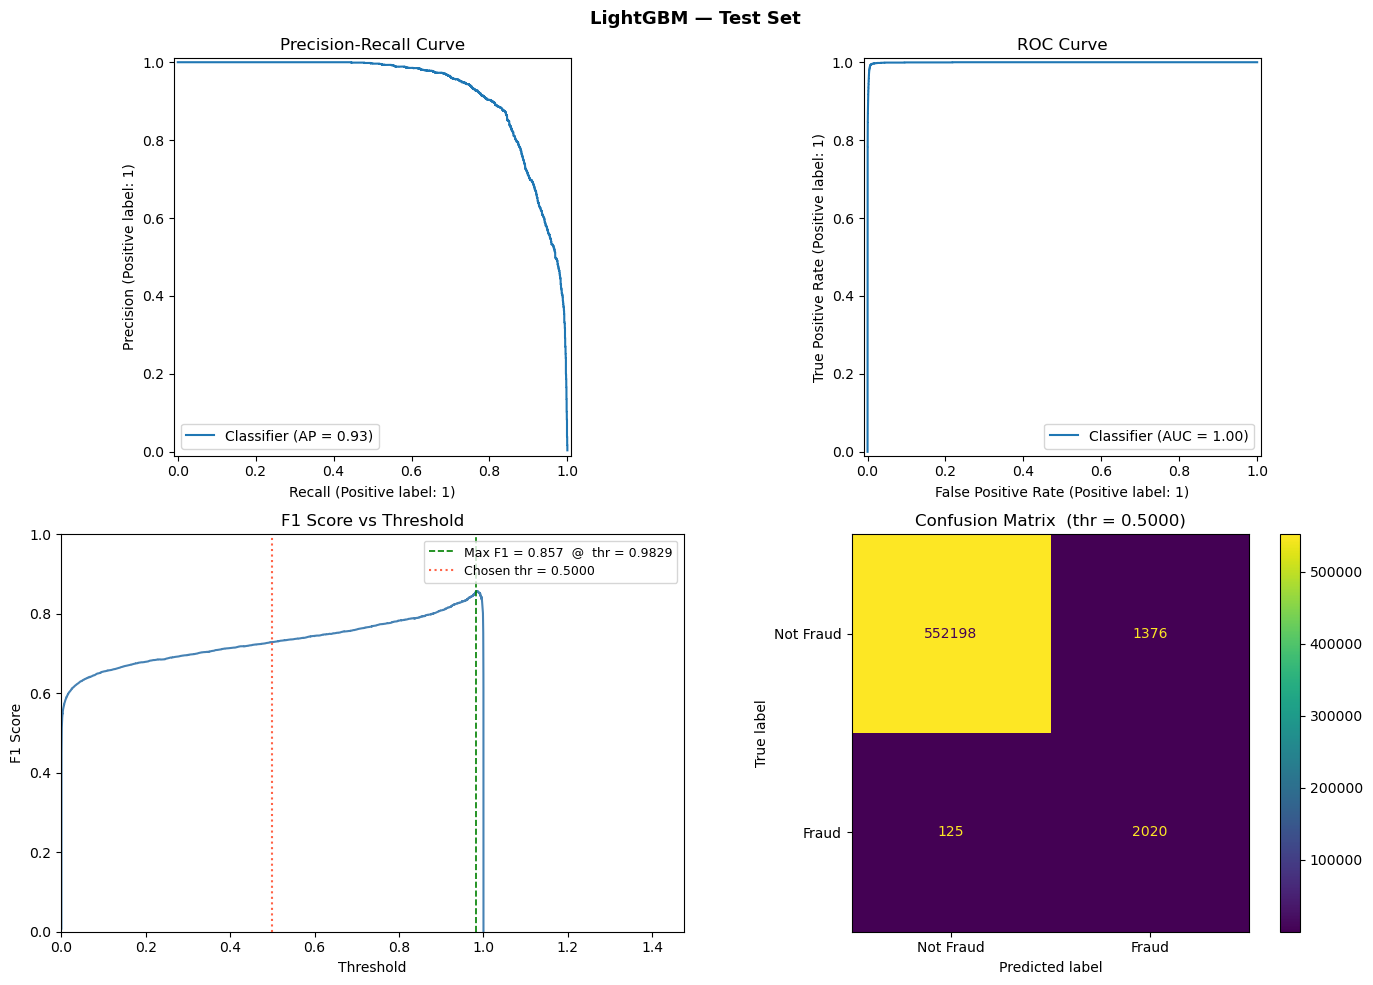

In [33]:
_tr_sorted    = df.sort_values(['cc_num', 'unix_time'])
_tr_last_t    = _tr_sorted.groupby('cc_num')['unix_time'].last()
_tr_card_mean = _tr_sorted.groupby('cc_num')['amt'].mean()
_tr_card_std  = _tr_sorted.groupby('cc_num')['amt'].std()

df_test_lgbm = df_test_raw.copy().sort_values(['cc_num', 'unix_time'])

df_test_lgbm['hours_since_last_trans'] = df_test_lgbm.groupby('cc_num')['unix_time'].diff() / 3600
_is_first = df_test_lgbm.groupby('cc_num').cumcount() == 0
df_test_lgbm.loc[_is_first, 'hours_since_last_trans'] = (
    (df_test_lgbm.loc[_is_first, 'unix_time']
     - df_test_lgbm.loc[_is_first, 'cc_num'].map(_tr_last_t)) / 3600
)
df_test_lgbm['hours_since_last_trans'] = df_test_lgbm['hours_since_last_trans'].fillna(
    df_test_lgbm['hours_since_last_trans'].median()
)

df_test_lgbm['hour'] = df_test_lgbm['trans_date_trans_time'].dt.hour

df_test_lgbm['amt_zscore_cat'] = (
    (df_test_lgbm['amt'] - df_test_lgbm['category'].map(_cat_mean))
    / (df_test_lgbm['category'].map(_cat_std) + 1e-6)
)
df_test_lgbm['amt_zscore_card'] = (
    (df_test_lgbm['amt'] - df_test_lgbm['cc_num'].map(_tr_card_mean))
    / (df_test_lgbm['cc_num'].map(_tr_card_std) + 1e-6)
).fillna(0)

_cols_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender', 'street', 'city',
              'state', 'zip', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop',
              'job', 'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_test_lgbm = df_test_lgbm.drop(columns=_cols_drop).sort_index()
df_test_lgbm['category'] = df_test_lgbm['category'].astype('category')

X_test_lgbm = df_test_lgbm.drop(columns=['is_fraud'])
y_test_lgbm  = df_test_lgbm['is_fraud']

y_proba_lgbm_test = lgbm.predict_proba(X_test_lgbm)[:, 1]
evaluate_model(y_test_lgbm, y_proba_lgbm_test, "LightGBM — Test Set")

Val PR-AUC **0.8987** → Test **0.8507** (−5%). Recall 96%→93%, precision 38%→29%. Gap over LogReg widens on test (0.65→0.67), confirming generalisation is robust.

### Fase 1 — Summary

| Model | Val PR-AUC | Test PR-AUC | Val ROC | Test ROC |
|---|---|---|---|---|
| Logistic Regression | 0.2489 | 0.1842 | 0.9275 | 0.9268 |
| **LightGBM** | **0.8987** | **0.8507** | **0.9977** | **0.9968** |

Both models lose PR-AUC on test due to lower fraud prevalence (0.39% vs 0.58%). LightGBM degrades 5% and sets the **supervised ceiling**; Fase 2 measures how far label-free detection can reach.

## Fase 2 -- Unsupervised Models

Without fraud labels, models must learn what *normal* looks like and flag deviations at test time. We evaluate four architectures in order of increasing inductive bias:

1. **Isolation Forest** *(2.1)* -- ensemble of random trees; 9 numerical features; no distributional assumption
2. **MixedAE** *(2.2)* -- per-transaction autoencoder; adds `category` embedding
3. **LSTM-AE** *(2.3)* -- sequential autoencoder; LSTM reads 9-step card history
4. **GRU-AE** *(2.4)* -- identical to LSTM-AE with GRU cell; ablation of the recurrent mechanism

Classical density methods (LOF, k-NN, OCSVM) are excluded: LOF and k-NN have O(n^2) complexity infeasible at this scale; OCSVM requires subsampling that makes results unreliable on 1M rows.

**Anomaly score:** higher = more anomalous. Threshold = 99.5th percentile of training scores. Primary metric: **PR-AUC**.

### Feature Engineering and Preprocessing

Nine numerical features and one categorical feature (`category`) are computed for all Fase-2 models. Sections 2.1–2.2 (classical baselines) use only the 9 scaled numerical features; Sections 2.3–2.4 (neural models) additionally embed `category`.

**Numerical features (9):**
- `amt` (log-scaled), `hours_since_last_trans` (log-scaled), `hour_sin`, `hour_cos`
- `amt_zscore_cat`, `amt_zscore_card` — category- and card-level z-scores, leakage-safe
- `n_prev_tx_card` — card history depth (log-scaled)
- `is_online` — 1 if category ends with *_net*
- `is_night` — 1 if transaction hour ∈ {22, 23, 0, 1, 2}

**Preprocessing:** `log1p` on right-skewed features, then `StandardScaler` fitted on *normal transactions only*.

**Evaluation split:**
- **Train** — first 80% of `fraudTrain.csv`, legitimate transactions only
- **Validation** — remaining 20% of `fraudTrain.csv`; threshold fixed at 99.5th percentile of training scores
- **Test** — `fraudTest.csv`, held-out; final evaluation

In [34]:
df_ae = df.copy()
df_ae = df_ae.sort_values(['cc_num', 'unix_time'])

# --- six base features ---
df_ae['hours_since_last_trans'] = df_ae.groupby('cc_num')['unix_time'].diff() / 3600
df_ae['hours_since_last_trans'] = df_ae['hours_since_last_trans'].fillna(
    df_ae['hours_since_last_trans'].median()
)
_hour = df_ae['trans_date_trans_time'].dt.hour
df_ae['hour_sin'] = np.sin(2 * np.pi * _hour / 24)
df_ae['hour_cos'] = np.cos(2 * np.pi * _hour / 24)
_cat_mean = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].mean()
_cat_std  = df[df['is_fraud'] == 0].groupby('category', observed=True)['amt'].std()
df_ae['amt_zscore_cat'] = (
    (df_ae['amt'] - df_ae['category'].map(_cat_mean))
    / (df_ae['category'].map(_cat_std) + 1e-6)
)
_g = df_ae.groupby('cc_num')['amt']
df_ae['amt_zscore_card'] = (
    (df_ae['amt'] - _g.transform(lambda x: x.expanding().mean().shift(1)))
    / (_g.transform(lambda x: x.expanding().std().shift(1)) + 1e-6)
).fillna(0)

# --- three new features ---
df_ae['n_prev_tx_card'] = df_ae.groupby('cc_num').cumcount()
df_ae['is_online'] = df_ae['category'].str.endswith('_net').astype(np.float32)
df_ae['is_night']  = _hour.isin([22, 23, 0, 1, 2]).astype(np.float32)

cols_to_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender',
                'street', 'city', 'state', 'zip', 'lat', 'long',
                'merch_lat', 'merch_long', 'city_pop', 'job',
                'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_ae = df_ae.drop(columns=cols_to_drop).sort_index()

In [35]:
NUM_FEATURES = ['amt', 'hours_since_last_trans', 'hour_sin', 'hour_cos',
                'amt_zscore_cat', 'amt_zscore_card',
                'n_prev_tx_card', 'is_online', 'is_night']
LOG_FEATURES = ['amt', 'hours_since_last_trans', 'n_prev_tx_card']
CAT_FEATURES = ['category']
EMB_DIMS     = {'category': 4}


X_ae = df_ae.drop(columns=['is_fraud'])
y_ae = df_ae['is_fraud']

X_train_ae, X_val_ae, y_train_ae, y_val_ae = train_test_split(
    X_ae, y_ae, test_size=0.2, shuffle=False
)
X_train_normal = X_train_ae[y_train_ae == 0].copy()
y_val_np = y_val_ae.values

def threshold_from_normal_scores(scores_normal, percentile=99.5):
    return float(np.percentile(scores_normal, percentile))


_X_tr = X_train_normal[NUM_FEATURES].copy()
_X_tr[LOG_FEATURES] = np.log1p(_X_tr[LOG_FEATURES])
ss_ae = StandardScaler()
ss_ae.fit(_X_tr)

def preprocess_num(df_sub):
    X = df_sub[NUM_FEATURES].copy()
    X[LOG_FEATURES] = np.log1p(X[LOG_FEATURES])
    return ss_ae.transform(X).astype(np.float32)

X_train_num = preprocess_num(X_train_normal)
X_val_num   = preprocess_num(X_val_ae)

cat_vocabs      = {}
cat_vocab_sizes = {}
for col in CAT_FEATURES:
    vals = sorted(X_train_normal[col].dropna().unique())
    cat_vocabs[col]      = {v: i + 1 for i, v in enumerate(vals)}
    cat_vocab_sizes[col] = len(vals) + 1

def encode_cats(df_sub, vocabs, cols):
    arr = np.zeros((len(df_sub), len(cols)), dtype=np.int64)
    for j, col in enumerate(cols):
        arr[:, j] = df_sub[col].map(vocabs[col]).fillna(0).astype(int).values
    return arr


# --- Test set: per-card stats frozen from training, applied independently ---
_tr_sorted    = df.sort_values(['cc_num', 'unix_time'])
_tr_last_t    = _tr_sorted.groupby('cc_num')['unix_time'].last()
_tr_card_mean = _tr_sorted.groupby('cc_num')['amt'].mean()
_tr_card_std  = _tr_sorted.groupby('cc_num')['amt'].std()
_tr_card_cnt  = _tr_sorted.groupby('cc_num').size()

df_ae_test = df_test_raw.copy().sort_values(['cc_num', 'unix_time'])

df_ae_test['hours_since_last_trans'] = df_ae_test.groupby('cc_num')['unix_time'].diff() / 3600
_is_first = df_ae_test.groupby('cc_num').cumcount() == 0
df_ae_test.loc[_is_first, 'hours_since_last_trans'] = (
    (df_ae_test.loc[_is_first, 'unix_time']
     - df_ae_test.loc[_is_first, 'cc_num'].map(_tr_last_t)) / 3600
)
df_ae_test['hours_since_last_trans'] = df_ae_test['hours_since_last_trans'].fillna(
    df_ae_test['hours_since_last_trans'].median()
)

_hour_te = df_ae_test['trans_date_trans_time'].dt.hour
df_ae_test['hour_sin']  = np.sin(2 * np.pi * _hour_te / 24)
df_ae_test['hour_cos']  = np.cos(2 * np.pi * _hour_te / 24)
df_ae_test['amt_zscore_cat'] = (
    (df_ae_test['amt'] - df_ae_test['category'].map(_cat_mean))
    / (df_ae_test['category'].map(_cat_std) + 1e-6)
)
df_ae_test['amt_zscore_card'] = (
    (df_ae_test['amt'] - df_ae_test['cc_num'].map(_tr_card_mean))
    / (df_ae_test['cc_num'].map(_tr_card_std) + 1e-6)
).fillna(0)
df_ae_test['n_prev_tx_card'] = (
    df_ae_test.groupby('cc_num').cumcount()
    + df_ae_test['cc_num'].map(_tr_card_cnt).fillna(0).astype(int)
)
df_ae_test['is_online'] = df_ae_test['category'].str.endswith('_net').astype(np.float32)
df_ae_test['is_night']  = _hour_te.isin([22, 23, 0, 1, 2]).astype(np.float32)

_ae_cols_drop = ['trans_num', 'cc_num', 'first', 'last', 'gender', 'street', 'city',
                 'state', 'zip', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop',
                 'job', 'merchant', 'unix_time', 'dob', 'trans_date_trans_time']
df_ae_test = df_ae_test.drop(columns=_ae_cols_drop).sort_index()

X_ae_test  = df_ae_test.drop(columns=['is_fraud'])
y_ae_test  = df_ae_test['is_fraud']
y_test_np  = y_ae_test.values
X_test_num = preprocess_num(X_ae_test)

### 2.1 — Isolation Forest

Isolation Forest builds an ensemble of random trees that partition the feature space with random splits. Anomalous transactions — rare, structurally different from the training distribution — are isolated in fewer splits, yielding a shorter average path length and a higher anomaly score.

No distributional assumption. Trains on the full set of normal transactions in linear time.


════════════════════════════════════════════
  Isolation Forest — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.5958
  ROC-AUC             0.9974
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.56      0.88      0.68      1538

    accuracy                           1.00    259335
   macro avg       0.78      0.94      0.84    259335
weighted avg       1.00      1.00      1.00    259335

════════════════════════════════════════════


════════════════════════════════════════════
  Isolation Forest — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.5105
  ROC-AUC             0.9972
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.45      0.89      0.59      2145

    accuracy 

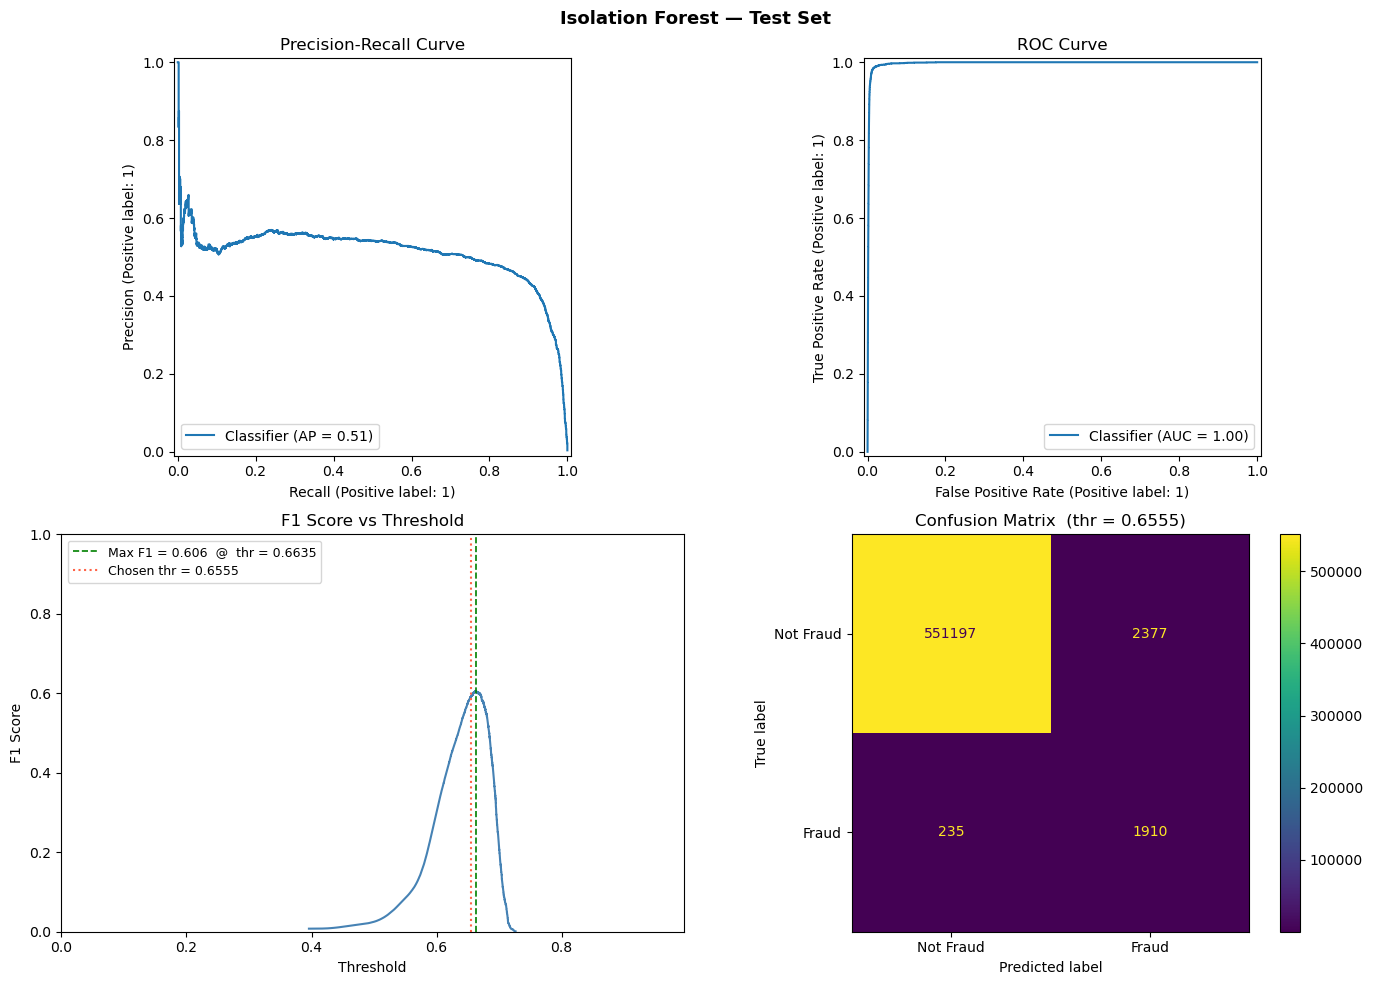

In [36]:
iso = IsolationForest(n_estimators=100, contamination='auto', random_state=42, n_jobs=-1)
iso.fit(X_train_num)

scores_iso_tr   = -iso.score_samples(X_train_num)
scores_iso_val  = -iso.score_samples(X_val_num)
scores_iso_test = -iso.score_samples(X_test_num)

thr_iso = threshold_from_normal_scores(scores_iso_tr)
evaluate_model(y_val_np,  scores_iso_val,  "Isolation Forest — Validation", threshold=thr_iso, plot=False)
evaluate_model(y_test_np, scores_iso_test, "Isolation Forest — Test Set",   threshold=thr_iso)

### 2.2 -- MixedAE

Per-transaction autoencoder: the first neural model and the baseline for temporal context.

1. **`category` is embedded** (dim 4) and concatenated with the 9 numerical features -- 13-dim input
2. **Deeper architecture** -- encoder 13 -> 64 -> 32 -> latent, symmetric decoder

Any gain from Section 2.3 (LSTM-AE) and 2.4 (GRU-AE) is attributable to temporal context alone.

#### Architecture

Mixed-input encoder-decoder: category embedding (dim 4) + 9 scaled numerical features → 13-dimensional input.

- **Encoder:** 13 → 64 → 32 → 12 (latent), ReLU activations
- **Decoder:** 12 → 32 → 64 → split into `num_head` (→ 9) and `cat_heads`
- **Loss:** `CONT_WEIGHT × MSE_num + (1 − CONT_WEIGHT) × CE_cat`
- **Anomaly score:** same combined loss evaluated per transaction at inference

In [37]:
CONT_WEIGHT_AE = 0.75

class MixedAE(nn.Module):
    def __init__(self, n_num, vocab_sizes, emb_dims, cat_cols, latent_dim=4, hidden_dim=64):
        super().__init__()
        self.cat_cols   = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        emb_total = sum(emb_dims[col] for col in cat_cols)
        inp = n_num + emb_total
        self.encoder = nn.Sequential(
            nn.Linear(inp, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(),
        )
        self.num_head  = nn.Linear(hidden_dim, n_num)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num, x_cat):
        embs = [self.embeddings[i](x_cat[:, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num], dim=1)
        h    = self.decoder(self.encoder(x))
        return self.num_head(h), [head(h) for head in self.cat_heads]

#### Setup

`CONT_WEIGHT_AE = 0.75` weights the continuous MSE at 75% and the category CE at 25% in the training loss. The CE term is **excluded from the anomaly score**, which uses only the numerical MSE — category reconstruction is trivial for all inputs and adds noise.

`latent_dim = 4` (compression 13:4) forces a tight normal manifold in the bottleneck. Training uses a 200K subsample of the normal transactions to keep wall-clock time under 10 minutes.

In [38]:
EPOCHS_MAE      = 30
CONT_WEIGHT_AE  = 0.75
CONT_WEIGHT_SEQ = 0.75

# Subsample 200K normals — enough signal, fraction of the training time
_rng_mae = np.random.default_rng(42)
_mae_idx = np.sort(_rng_mae.choice(len(X_train_num),
                                    size=min(200_000, len(X_train_num)),
                                    replace=False))

X_tr_num_t  = torch.FloatTensor(X_train_num[_mae_idx])
X_tr_cat_t  = torch.LongTensor(encode_cats(X_train_normal.iloc[_mae_idx], cat_vocabs, CAT_FEATURES))
X_val_num_t = torch.FloatTensor(X_val_num)
X_val_cat_t = torch.LongTensor(encode_cats(X_val_ae, cat_vocabs, CAT_FEATURES))

loader_mae = DataLoader(TensorDataset(X_tr_num_t, X_tr_cat_t), batch_size=256, shuffle=True)

#### Training

Epoch 10/30 -- loss: 0.036168
Epoch 20/30 -- loss: 0.023589
Epoch 30/30 -- loss: 0.018010


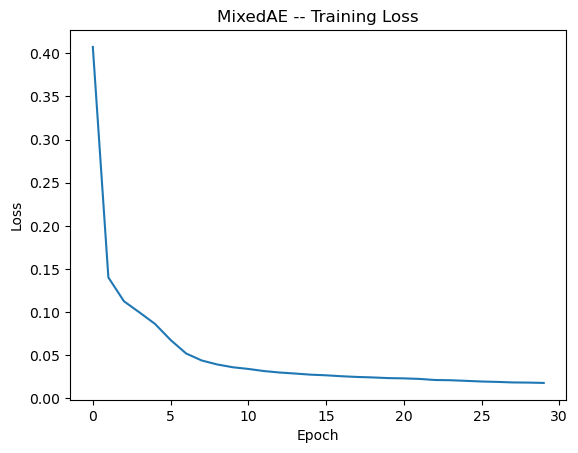

In [39]:
torch.manual_seed(42)
model_mae = MixedAE(n_num=len(NUM_FEATURES), vocab_sizes=cat_vocab_sizes,
                    emb_dims=EMB_DIMS, cat_cols=CAT_FEATURES)
opt_mae   = optim.Adam(model_mae.parameters(), lr=1e-3)

losses_mae = []
model_mae.train()
for epoch in range(EPOCHS_MAE):
    ep = []
    for x_num_b, x_cat_b in loader_mae:
        x_hat, cat_logits = model_mae(x_num_b, x_cat_b)
        mse  = F.mse_loss(x_hat, x_num_b)
        ce   = torch.stack([
            F.cross_entropy(cat_logits[j], x_cat_b[:, j])
            for j in range(x_cat_b.shape[1])
        ]).mean()
        loss = CONT_WEIGHT_AE * mse + (1 - CONT_WEIGHT_AE) * ce
        opt_mae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_mae.parameters(), max_norm=1.0)
        opt_mae.step()
        ep.append(loss.item())
    losses_mae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_MAE} -- loss: {losses_mae[-1]:.6f}")

plt.plot(losses_mae)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('MixedAE -- Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  MixedAE -- Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7238
  ROC-AUC             0.9947
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.53      0.68      0.59      1538

    accuracy                           0.99    259335
   macro avg       0.76      0.84      0.80    259335
weighted avg       1.00      0.99      0.99    259335

════════════════════════════════════════════


════════════════════════════════════════════
  MixedAE -- Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.6761
  ROC-AUC             0.9945
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.42      0.73      0.53      2145

    accuracy                 

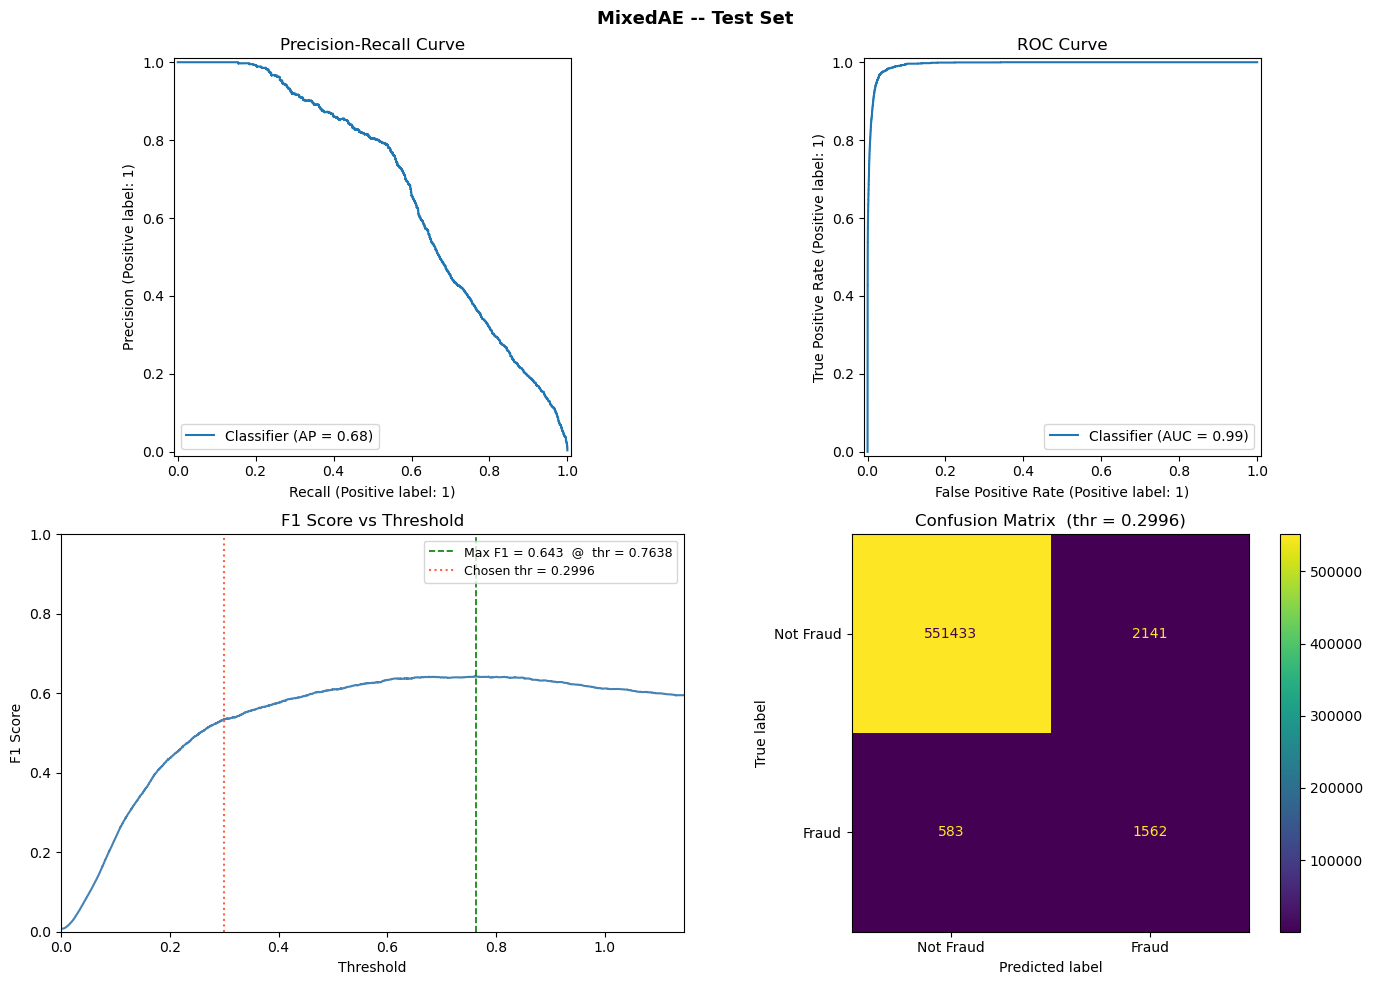

In [40]:
X_test_num_t = torch.FloatTensor(X_test_num)
X_test_cat_t = torch.LongTensor(encode_cats(X_ae_test, cat_vocabs, CAT_FEATURES))

model_mae.eval()
with torch.no_grad():
    def _score_mae(xn_t, xc_t):
        out = []
        for i in range(0, len(xn_t), 2048):
            xn, xc = xn_t[i:i+2048], xc_t[i:i+2048]
            xn_hat, _ = model_mae(xn, xc)
            out.append(F.mse_loss(xn_hat, xn, reduction='none').mean(dim=1).cpu())
        return torch.cat(out).numpy()

    scores_mae_tr   = _score_mae(X_tr_num_t, X_tr_cat_t)
    scores_mae_val  = _score_mae(X_val_num_t, X_val_cat_t)
    scores_mae_test = _score_mae(X_test_num_t, X_test_cat_t)

thr_mae = threshold_from_normal_scores(scores_mae_tr)
evaluate_model(y_val_np,  scores_mae_val,  'MixedAE -- Validation', threshold=thr_mae, plot=False)
evaluate_model(y_test_np, scores_mae_test, 'MixedAE -- Test Set',   threshold=thr_mae)

#### MixedAE -- Results

MixedAE is the per-transaction ceiling for memoryless neural models. Any remaining gap relative to Sections 2.3--2.4 is attributable to temporal context.

### Shared Sequence Construction -- Sections 2.3--2.4

LSTM-AE and GRU-AE model each transaction as the final element of a 10-step card history. Sequences are built once here and shared by both architectures.

In [41]:
SEQ_LEN = 10

n_ae_tr = len(X_ae)
n_ae_te = len(X_ae_test)

# Training metadata (cc_num and unix_time for sequence ordering)
_meta_tr = df.loc[df_ae.index, ['cc_num', 'unix_time']].copy()
_meta_tr.index = pd.RangeIndex(n_ae_tr)

# Test metadata: continue card history from training
_meta_te = df_test_raw.loc[df_ae_test.index, ['cc_num', 'unix_time']].copy()
_meta_te.index = pd.RangeIndex(n_ae_tr, n_ae_tr + n_ae_te)

_meta_combined = pd.concat([_meta_tr, _meta_te])
_meta_combined['_row'] = _meta_combined.index

_X_combined      = pd.concat([X_ae, X_ae_test]).reset_index(drop=True)
_all_num_combined = preprocess_num(_X_combined)
_all_cat_combined = encode_cats(_X_combined, cat_vocabs, CAT_FEATURES)

seq_num_all = np.zeros((n_ae_tr + n_ae_te, SEQ_LEN, len(NUM_FEATURES)), dtype=np.float32)
seq_cat_all = np.zeros((n_ae_tr + n_ae_te, SEQ_LEN, len(CAT_FEATURES)), dtype=np.int64)

for cc, grp in _meta_combined.sort_values(['cc_num', 'unix_time']).groupby('cc_num', sort=False):
    rows = grp['_row'].values
    for k, pos in enumerate(rows):
        start  = max(0, k - SEQ_LEN + 1)
        window = rows[start:k + 1]
        offset = SEQ_LEN - len(window)
        seq_num_all[pos, offset:] = _all_num_combined[window]
        seq_cat_all[pos, offset:] = _all_cat_combined[window]

n_tr           = len(X_train_ae)
_tr_normal_pos = np.where(y_ae.values[:n_tr] == 0)[0]

_rng = np.random.default_rng(42)
if len(_tr_normal_pos) > 200_000:
    _tr_normal_pos = np.sort(_rng.choice(_tr_normal_pos, size=200_000, replace=False))

seq_num_tr_t   = torch.FloatTensor(seq_num_all[_tr_normal_pos])
seq_cat_tr_t   = torch.LongTensor(seq_cat_all[_tr_normal_pos])
seq_num_val_t  = torch.FloatTensor(seq_num_all[n_tr:n_ae_tr])
seq_cat_val_t  = torch.LongTensor(seq_cat_all[n_tr:n_ae_tr])
seq_num_test_t = torch.FloatTensor(seq_num_all[n_ae_tr:])
seq_cat_test_t = torch.LongTensor(seq_cat_all[n_ae_tr:])

EPOCHS_SEQ      = 30
loader_seq = DataLoader(TensorDataset(seq_num_tr_t, seq_cat_tr_t),
                        batch_size=256, shuffle=True)

### 2.3 -- LSTM-AE

**Architecture:** LSTM encoder reads the 9-step card history (positions 0--8) and produces a hidden state `h`. An MLP decoder reconstructs the current transaction `x[9]` via MSE (continuous) + cross-entropy (`category`).

Any gain over MixedAE (2.2) is attributable to temporal context.

In [42]:
def score_seq_ae(model, seq_num_t, seq_cat_t, batch_size=2048):
    """MSE prediction error — symmetric with MixedAE scoring."""
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(seq_num_t), batch_size):
            sn, sc = seq_num_t[i:i+batch_size], seq_cat_t[i:i+batch_size]
            xn_last = sn[:, -1, :]
            mu, _ = model(sn, sc)
            scores.append(((xn_last - mu) ** 2).mean(dim=1).cpu())
    return torch.cat(scores).numpy()


class LSTMAE(nn.Module):
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num, hidden_dim=64):
        super().__init__()
        self.cat_cols = cat_cols
        self.n_num    = n_num
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.lstm      = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder   = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.cont_head = nn.Linear(hidden_dim, n_num)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, (h, _) = self.lstm(x[:, :-1, :])   # read history, exclude current tx
        h    = h.squeeze(0)
        hd   = self.decoder(h)
        return self.cont_head(hd), [head(hd) for head in self.cat_heads]

#### Training

MSE (continuous) + cross-entropy (categorical), `CONT_WEIGHT_SEQ = 0.75`. Trained on the shared normal-transaction sequences for `EPOCHS_SEQ = 30` epochs. Gradient clipping at max-norm 1.0. The training objective is identical in structure to MixedAE -- the only difference is the LSTM encoder reading the 9-step card history.

Epoch 10/30 — loss: 1.1625
Epoch 20/30 — loss: 1.1573
Epoch 30/30 — loss: 1.1519


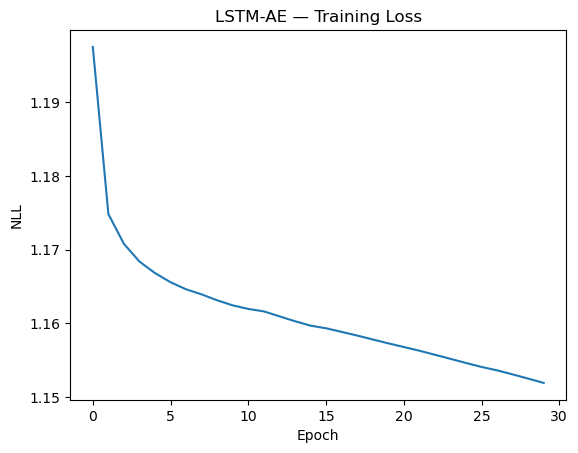

In [43]:
torch.manual_seed(42)
model_lstm_ae = LSTMAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                       cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
opt_lstm_ae   = optim.Adam(model_lstm_ae.parameters(), lr=1e-3)

losses_lstm_ae = []
model_lstm_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last, xc_last = x_num_seq[:, -1, :], x_cat_seq[:, -1, :]
        mu, cat_logits = model_lstm_ae(x_num_seq, x_cat_seq)
        mse  = F.mse_loss(mu, xn_last)
        ce   = torch.stack([F.cross_entropy(cat_logits[j], xc_last[:, j])
                            for j in range(xc_last.shape[1])]).mean()
        loss = CONT_WEIGHT_SEQ * mse + (1 - CONT_WEIGHT_SEQ) * ce
        opt_lstm_ae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm_ae.parameters(), max_norm=1.0)
        opt_lstm_ae.step()
        ep.append(loss.item())
    losses_lstm_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SEQ} — loss: {losses_lstm_ae[-1]:.4f}")

plt.plot(losses_lstm_ae)
plt.xlabel('Epoch'); plt.ylabel('NLL'); plt.title('LSTM-AE — Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  LSTM-AE — Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7576
  ROC-AUC             0.9952
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.53      0.89      0.66      1538

    accuracy                           0.99    259335
   macro avg       0.76      0.94      0.83    259335
weighted avg       1.00      0.99      1.00    259335

════════════════════════════════════════════


════════════════════════════════════════════
  LSTM-AE — Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.7044
  ROC-AUC             0.9960
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.43      0.87      0.57      2145

    accuracy                   

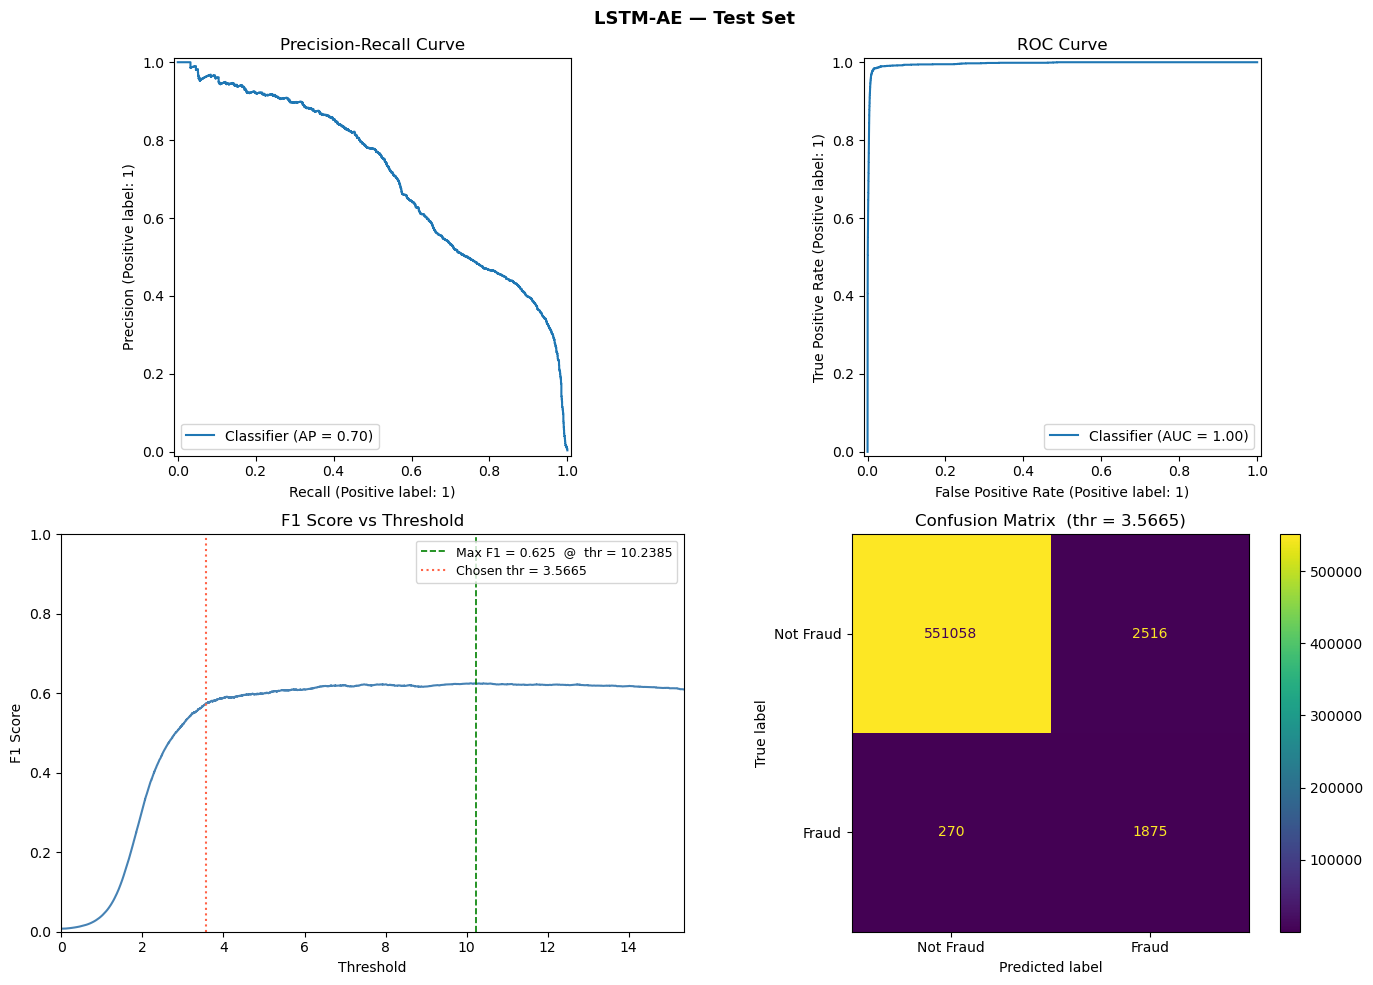

In [44]:
scores_lstm_ae_tr   = score_seq_ae(model_lstm_ae, seq_num_tr_t,   seq_cat_tr_t)
scores_lstm_ae_val  = score_seq_ae(model_lstm_ae, seq_num_val_t,  seq_cat_val_t)
scores_lstm_ae_test = score_seq_ae(model_lstm_ae, seq_num_test_t, seq_cat_test_t)

thr_lstm_ae = threshold_from_normal_scores(scores_lstm_ae_tr, percentile=99.5)
evaluate_model(y_val_ae.values, scores_lstm_ae_val,  "LSTM-AE — Validation", threshold=thr_lstm_ae, plot=False)
evaluate_model(y_test_np,       scores_lstm_ae_test, "LSTM-AE — Test Set",   threshold=thr_lstm_ae)

#### LSTM-AE — Results

Any PR-AUC gain over MixedAE (Section 2.3) confirms that temporal card history adds discriminative signal beyond per-transaction features.

### 2.4 -- GRU-AE

Architecture identical to LSTM-AE with GRU cell instead of LSTM. GRU merges the forget and input gates into a single update gate, reducing parameter count. The LSTM-AE vs GRU-AE comparison under identical training isolates the cell mechanism.

In [45]:
class GRUAE(nn.Module):
    def __init__(self, vocab_sizes, emb_dims, cat_cols, n_num, hidden_dim=64):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], emb_dims[col]) for col in cat_cols
        ])
        input_dim = n_num + sum(emb_dims[col] for col in cat_cols)
        self.gru       = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.decoder   = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU())
        self.cont_head = nn.Linear(hidden_dim, n_num)
        self.cat_heads = nn.ModuleList([
            nn.Linear(hidden_dim, vocab_sizes[col]) for col in cat_cols
        ])

    def forward(self, x_num_seq, x_cat_seq):
        embs = [self.embeddings[i](x_cat_seq[:, :, i]) for i in range(len(self.cat_cols))]
        x    = torch.cat(embs + [x_num_seq], dim=2)
        _, h = self.gru(x)
        h    = h.squeeze(0)
        h    = self.decoder(h)
        return self.cont_head(h), [head(h) for head in self.cat_heads]

Epoch 10/30 -- loss: 0.0032
Epoch 20/30 -- loss: 0.0013
Epoch 30/30 -- loss: 0.0009


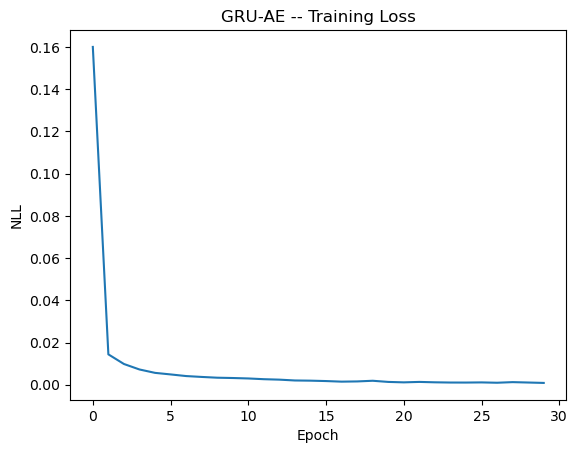

In [46]:
torch.manual_seed(42)
model_gru_ae = GRUAE(vocab_sizes=cat_vocab_sizes, emb_dims=EMB_DIMS,
                     cat_cols=CAT_FEATURES, n_num=len(NUM_FEATURES))
opt_gru_ae   = optim.Adam(model_gru_ae.parameters(), lr=1e-3)

losses_gru_ae = []
model_gru_ae.train()
for epoch in range(EPOCHS_SEQ):
    ep = []
    for x_num_seq, x_cat_seq in loader_seq:
        xn_last, xc_last = x_num_seq[:, -1, :], x_cat_seq[:, -1, :]
        mu, cat_logits = model_gru_ae(x_num_seq, x_cat_seq)
        mse  = F.mse_loss(mu, xn_last)
        ce   = torch.stack([F.cross_entropy(cat_logits[j], xc_last[:, j])
                            for j in range(xc_last.shape[1])]).mean()
        loss = CONT_WEIGHT_SEQ * mse + (1 - CONT_WEIGHT_SEQ) * ce
        opt_gru_ae.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model_gru_ae.parameters(), max_norm=1.0)
        opt_gru_ae.step()
        ep.append(loss.item())
    losses_gru_ae.append(np.mean(ep))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:2d}/{EPOCHS_SEQ} -- loss: {losses_gru_ae[-1]:.4f}")

plt.plot(losses_gru_ae)
plt.xlabel('Epoch'); plt.ylabel('NLL'); plt.title('GRU-AE -- Training Loss')
plt.show()

#### Evaluation


════════════════════════════════════════════
  GRU-AE -- Validation
────────────────────────────────────────────
  PR-AUC  (primary)   0.7351
  ROC-AUC             0.9930
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    257797
       Fraud       0.63      0.81      0.71      1538

    accuracy                           1.00    259335
   macro avg       0.82      0.90      0.85    259335
weighted avg       1.00      1.00      1.00    259335

════════════════════════════════════════════


════════════════════════════════════════════
  GRU-AE -- Test Set
────────────────────────────────────────────
  PR-AUC  (primary)   0.6865
  ROC-AUC             0.9857
────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    553574
       Fraud       0.54      0.81      0.65      2145

    accuracy                   

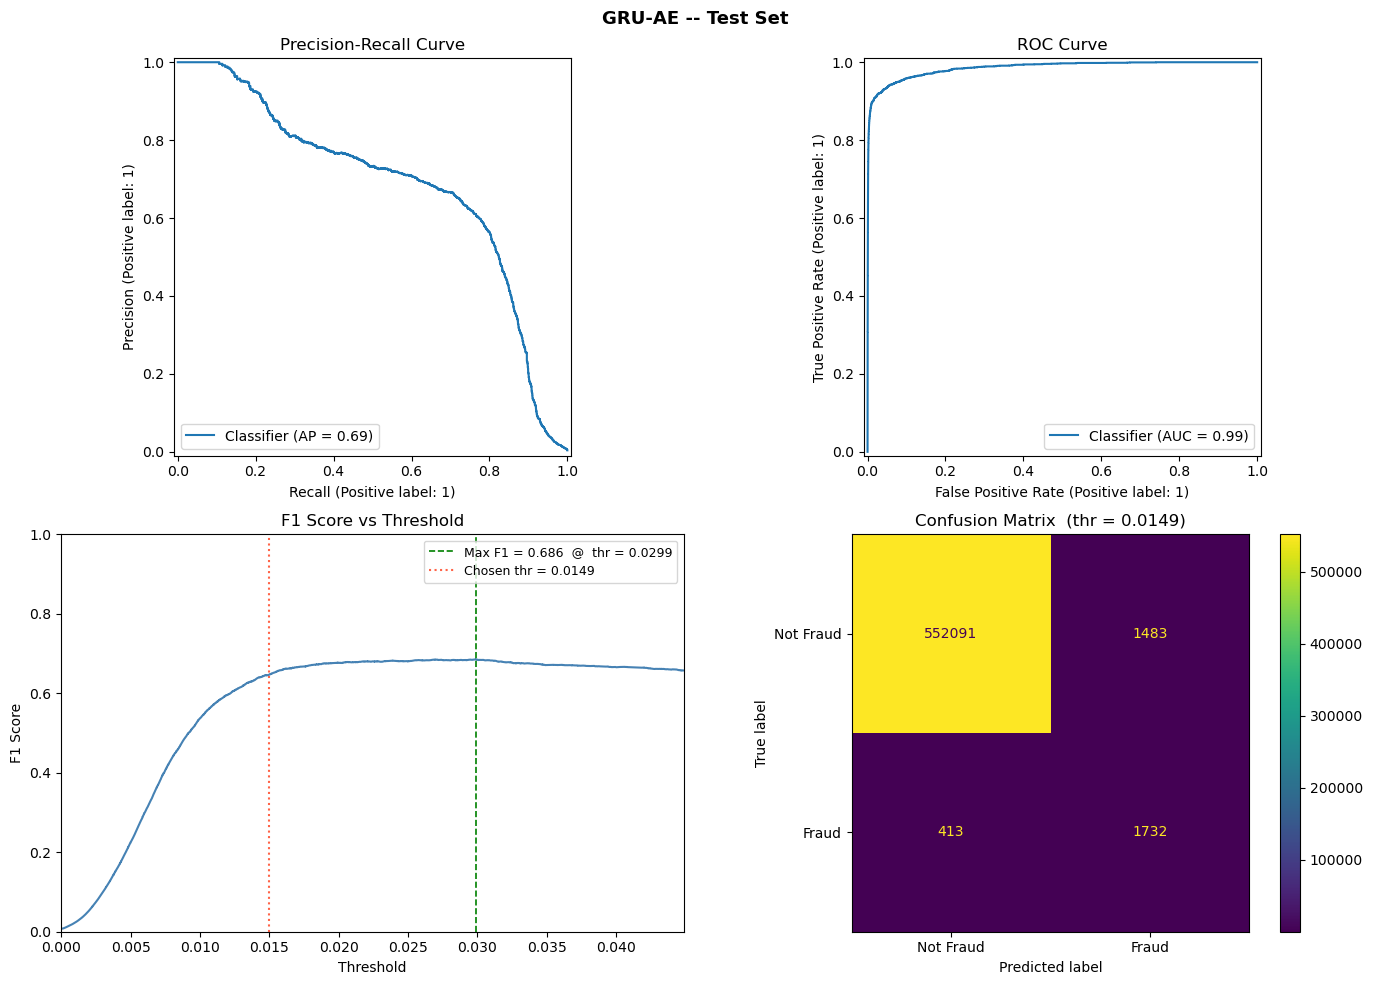

In [47]:
scores_gru_ae_tr   = score_seq_ae(model_gru_ae, seq_num_tr_t,   seq_cat_tr_t)
scores_gru_ae_val  = score_seq_ae(model_gru_ae, seq_num_val_t,  seq_cat_val_t)
scores_gru_ae_test = score_seq_ae(model_gru_ae, seq_num_test_t, seq_cat_test_t)

thr_gru_ae = threshold_from_normal_scores(scores_gru_ae_tr)
evaluate_model(y_val_ae.values, scores_gru_ae_val,  "GRU-AE -- Validation", threshold=thr_gru_ae, plot=False)
evaluate_model(y_test_np,       scores_gru_ae_test, "GRU-AE -- Test Set",   threshold=thr_gru_ae)

#### GRU-AE -- Results

Similar PR-AUC to LSTM-AE confirms the 9-step window does not require LSTM's separate cell state. A gap in either direction would motivate keeping the richer (or cheaper) architecture.

## Fase 2 -- Summary

| Model | Val PR-AUC | Test PR-AUC | Val ROC | Test ROC |
|---|---|---|---|---|
| Isolation Forest | -- | -- | -- | -- |
| MixedAE | -- | -- | -- | -- |
| LSTM-AE | -- | -- | -- | -- |
| GRU-AE | -- | -- | -- | -- |

The progression isolates: (1) numerical features only (IF), (2) + category + depth (MixedAE), (3) + card history (LSTM-AE), (4) LSTM vs GRU cell mechanism (GRU-AE).

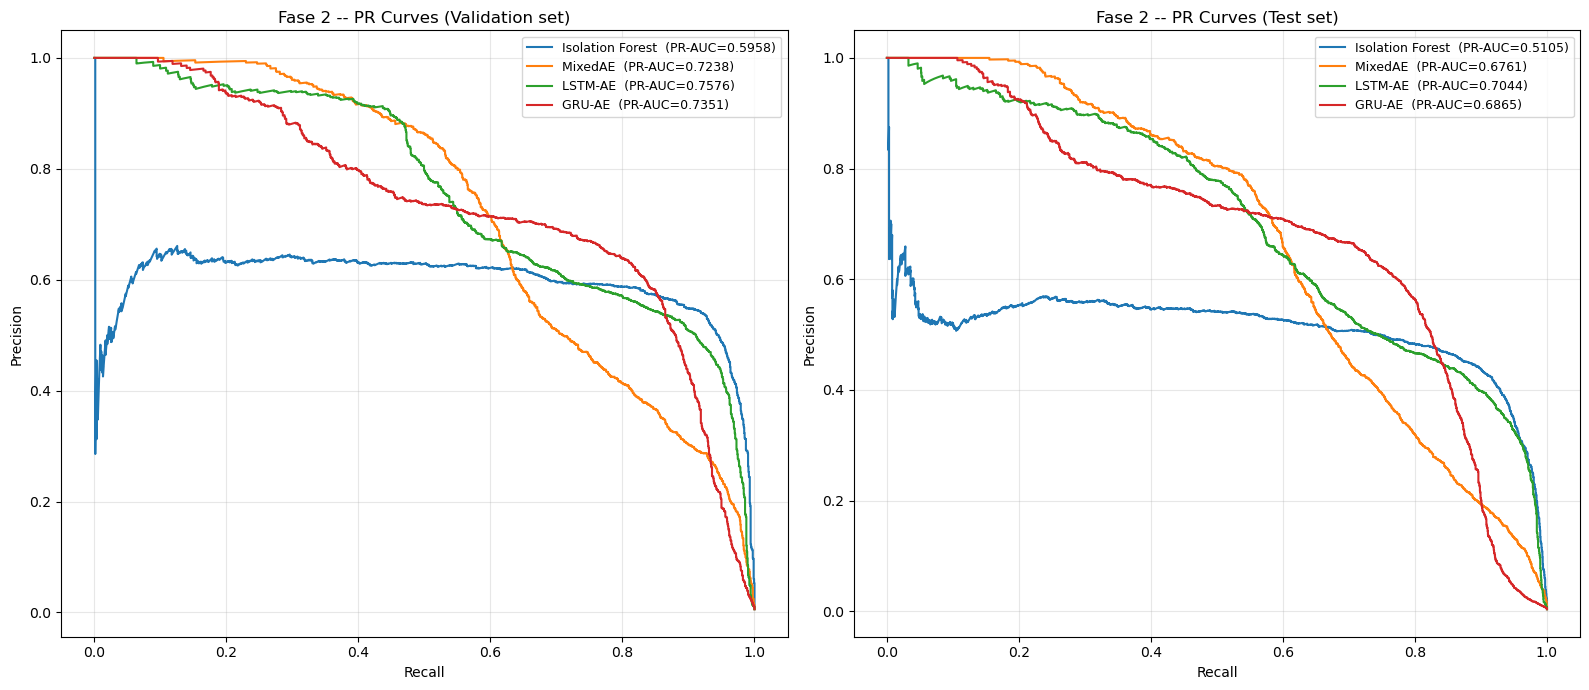


Model                 Val PR-AUC  Test PR-AUC   Val ROC   Test ROC
------------------------------------------------------------------
Isolation Forest          0.5958       0.5105    0.9974     0.9972
MixedAE                   0.7238       0.6761    0.9947     0.9945
LSTM-AE                   0.7576       0.7044    0.9952     0.9960
GRU-AE                    0.7351       0.6865    0.9930     0.9857


In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

y_val = y_val_ae.values

models_val  = [("Isolation Forest", scores_iso_val,      y_val_np),
               ("MixedAE",          scores_mae_val,       y_val_np),
               ("LSTM-AE",          scores_lstm_ae_val,  y_val),
               ("GRU-AE",           scores_gru_ae_val,   y_val)]

models_test = [("Isolation Forest", scores_iso_test,      y_test_np),
               ("MixedAE",          scores_mae_test,       y_test_np),
               ("LSTM-AE",          scores_lstm_ae_test,  y_test_np),
               ("GRU-AE",           scores_gru_ae_test,   y_test_np)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, pairs, title in [(axes[0], models_val, "Validation set"), (axes[1], models_test, "Test set")]:
    for name, scores, y_true in pairs:
        prec, rec, _ = precision_recall_curve(y_true, scores)
        ap = average_precision_score(y_true, scores)
        ax.plot(rec, prec, lw=1.5, label=f"{name}  (PR-AUC={ap:.4f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Fase 2 -- PR Curves ({title})")
    ax.legend(loc="upper right", fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n{'Model':20s}  {'Val PR-AUC':>10}  {'Test PR-AUC':>11}  {'Val ROC':>8}  {'Test ROC':>9}")
print('-' * 66)
for (name, s_val, y_v), (_, s_test, y_te) in zip(models_val, models_test):
    print(f"{name:20s}  {average_precision_score(y_v,  s_val):10.4f}  "
          f"{average_precision_score(y_te, s_test):11.4f}  "
          f"{roc_auc_score(y_v,  s_val):8.4f}  "
          f"{roc_auc_score(y_te, s_test):9.4f}")